# Análisis MANOVA: Efecto del Tráfico Escolar en Contaminantes Atmosféricos

**Objetivo:** Evaluar mediante MANOVA si el conjunto de contaminantes atmosféricos (CO, NO2, O3, PM10, PM2.5) presenta diferencias significativas entre días con clase y días sin clase.

## 0. Importación de Librerías y Carga de Datos

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, f, mannwhitneyu
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [31]:
df = pd.read_csv('../data_processed/dataset_wide_con_temporada.csv')
df['date'] = pd.to_datetime(df['date'])
df['clase'] = df['clase'].astype(int)

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (10907, 12)

Primeras filas:


,date,anio,mes,dia,estacion,clase,CO,NO2,O3,PM10,PM2.5,temporada
0,2023-01-01 07:00:00,2023,1,1,CENTRO,0,1.040000,13.600000,16.000000,84.000000,35.00,invierno
1,2023-01-01 07:00:00,2023,1,1,NORESTE3,0,1.556333,27.100000,6.600000,140.666667,74.50,invierno
2,2023-01-01 07:00:00,2023,1,1,NOROESTE3,0,1.390000,18.666667,7.333333,57.333333,21.96,invierno
3,2023-01-01 07:00:00,2023,1,1,NORTE2,0,1.675000,29.400000,6.500000,162.500000,68.01,invierno
4,2023-01-01 07:00:00,2023,1,1,SUR,0,1.787500,43.625000,6.750000,99.250000,41.44,invierno


In [32]:
df_clean = df[contaminantes + ['clase', 'temporada', 'estacion']].dropna()
print(f"Datos después de eliminar NA: {df_clean.shape}")
print(f"\nDistribución de clase:")
print(df_clean['clase'].value_counts())
print(f"\nDistribución de temporada:")
print(df_clean['temporada'].value_counts())

Datos después de eliminar NA: (10016, 8)

Distribución de clase:
clase
0    6325
1    3691
Name: count, dtype: int64

Distribución de temporada:
temporada
otra        8295
invierno    1005
verano       716
Name: count, dtype: int64


## 1.1 Validación de Supuestos del MANOVA

### 1.1.0 Supuesto de Independencia de Observaciones


Los datos provienen de series temporales horarias, lo cual implica un riesgo de  autocorrelación temporal. Aunque se seleccionó únicamente la franja horaria 7–9 AM y se agregaron datos por día-estación, aun está la posibilidad de que observaciones cercanas en el tiempo estén correlacionadas debido a:

- Condiciones meteorológicas persistentes como una inversión térmica puede durar varios días
- Patrones de tráfico estacionales como el inicio de semestre vs. mitad de semestre
- Eventos externos como días festivos largos, vacacione

MANOVA asume que las observaciones son independientes e idénticamente distribuidas. Si este supuesto se viola, los errores estándar y p-valores pueden estar sesgados.

Para ver que si esto pasa seguiremos esto: 

1. Analizar autocorrelación en residuales del modelo
2. Evaluar si el agrupamiento por día-estación reduce suficientemente la dependencia temporal
3. Proponer alternativas robustas si la autocorrelación es significativa

In [33]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals_dict = {}

for contaminante in contaminantes:
    formula_temp = f'{contaminante} ~ clase'
    if contaminante == 'PM2.5':
        formula_temp = 'Q("PM2.5") ~ clase'
    
    modelo_temp = ols(formula_temp, data=df_clean).fit()
    residuals_dict[contaminante] = modelo_temp.resid

residuals_df = pd.DataFrame(residuals_dict)

dw_results = []
for contaminante in contaminantes:
    dw_stat = durbin_watson(residuals_dict[contaminante])
    dw_results.append({
        'Contaminante': contaminante,
        'Durbin-Watson': dw_stat,
        'Interpretación': 'Sin autocorrelación' if 1.5 < dw_stat < 2.5 else 
                         'Autocorrelación positiva' if dw_stat < 1.5 else 
                         'Autocorrelación negativa'
    })

dw_df = pd.DataFrame(dw_results)
print("Test de Durbin-Watson para Autocorrelación en Residuales")
print("=" * 70)
print("Valores esperados: ~2 indica independencia, <2 indica autocorrelación positiva")
print("=" * 70)
print(dw_df.to_string(index=False))

Test de Durbin-Watson para Autocorrelación en Residuales
Valores esperados: ~2 indica independencia, <2 indica autocorrelación positiva
Contaminante  Durbin-Watson           Interpretación
          CO       0.944918 Autocorrelación positiva
         NO2       0.878920 Autocorrelación positiva
          O3       0.761933 Autocorrelación positiva
        PM10       0.732519 Autocorrelación positiva
       PM2.5       0.869983 Autocorrelación positiva


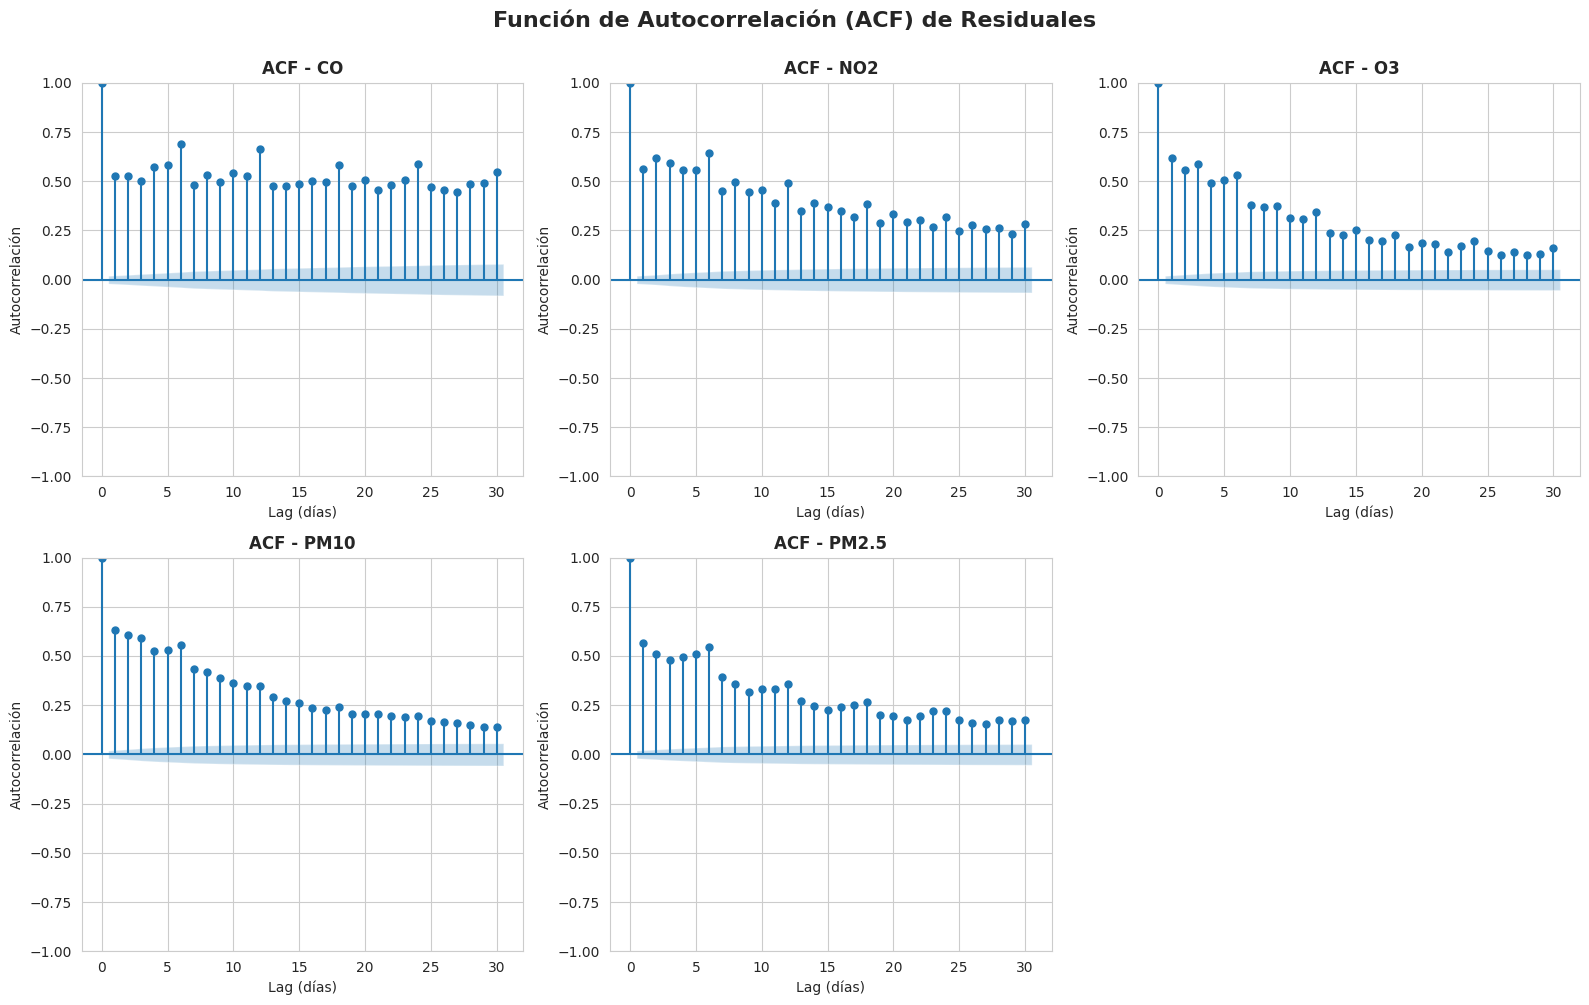

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    plot_acf(residuals_dict[contaminante], lags=30, ax=ax, alpha=0.05)
    ax.set_title(f'ACF - {contaminante}', fontsize=12, weight='bold')
    ax.set_xlabel('Lag (días)', fontsize=10)
    ax.set_ylabel('Autocorrelación', fontsize=10)

axes[-1].axis('off')

plt.suptitle('Función de Autocorrelación (ACF) de Residuales', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()



Los resultados del test de Durbin-Watson muestran que todos los contaminantes presentan autocorrelación positiva muy fuerte:

| Contaminante | DW | Interpretación |
|---|---|---|
| CO | 0.945 | Fuerte autocorrelación positiva |
| NO₂ | 0.879 | Fuerte autocorrelación positiva |
| O₃ | 0.762 | Muy fuerte autocorrelación positiva |
| PM₁₀ | 0.733 | Muy fuerte autocorrelación positiva |
| PM₂.₅ | 0.870 | Fuerte autocorrelación positiva |

**¿Qué significa DW < 1?**

Un valor DW de 0.73–0.95 indica que los residuales de un día están fuertemente correlacionados con el día anterior. Esto es típico en:
- Series ambientales donde las condiciones meteorológicas persisten
- Fenómenos atmosféricos (inversiones térmicas, patrones de circulación)
- Efectos de tráfico que no cambian drásticamente día a día

**Implicaciones para MANOVA:**

- Los p-valores de MANOVA pueden estar sesgados hacia abajo (artificialmente pequeños)
- Los errores estándar están subestimados
- La correlación temporal infla artificialmente la F-estadística


### 1.1.1 Supuesto de Normalidad Multivariada (Mardia's Test)

In [36]:
def mardia_test(data):
    n, p = data.shape
    data_centered = data - data.mean(axis=0)
    S = np.cov(data.T)
    S_inv = np.linalg.inv(S)
    
    D = np.array([data_centered[i] @ S_inv @ data_centered[i] for i in range(n)])
    
    b1p = np.mean(D**3)
    b2p = np.mean(D**2)
    
    skewness_stat = n * b1p / 6
    df_skew = p * (p + 1) * (p + 2) / 6
    p_skew = 1 - chi2.cdf(skewness_stat, df_skew)
    
    kurtosis_stat = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
    p_kurt = 2 * (1 - stats.norm.cdf(abs(kurtosis_stat)))
    
    return {
        'skewness': b1p,
        'skewness_stat': skewness_stat,
        'p_skewness': p_skew,
        'kurtosis': b2p,
        'kurtosis_stat': kurtosis_stat,
        'p_kurtosis': p_kurt
    }

X = df_clean[contaminantes].values
mardia_results = mardia_test(X)

print("Test de Mardia para Normalidad Multivariada")
print("=" * 50)
print(f"Asimetría multivariada (b1p): {mardia_results['skewness']:.4f}")
print(f"Estadístico chi-cuadrado: {mardia_results['skewness_stat']:.4f}")
print(f"p-valor: {mardia_results['p_skewness']:.4e}")
print(f"\nCurtosis multivariada (b2p): {mardia_results['kurtosis']:.4f}")
print(f"Estadístico Z: {mardia_results['kurtosis_stat']:.4f}")
print(f"p-valor: {mardia_results['p_kurtosis']:.4e}")

Test de Mardia para Normalidad Multivariada
Asimetría multivariada (b1p): 13407.9474
Estadístico chi-cuadrado: 22382333.4758
p-valor: 0.0000e+00

Curtosis multivariada (b2p): 103.0642
Estadístico Z: 407.0868
p-valor: 0.0000e+00


Se rechaza normalidad

### 1.1.2 Supuesto de Homogeneidad de Matrices de Covarianza (Box's M Test)

In [37]:
def box_m_test(data, group):
    groups = np.unique(group)
    n_groups = len(groups)
    p = data.shape[1]
    
    cov_matrices = []
    n_samples = []
    
    for g in groups:
        group_data = data[group == g]
        n_samples.append(len(group_data))
        cov_matrices.append(np.cov(group_data.T))
    
    n_total = sum(n_samples)
    pooled_cov = sum([(n - 1) * cov for n, cov in zip(n_samples, cov_matrices)]) / (n_total - n_groups)
    
    M = (n_total - n_groups) * np.log(np.linalg.det(pooled_cov))
    for n, cov in zip(n_samples, cov_matrices):
        M -= (n - 1) * np.log(np.linalg.det(cov))
    
    c1 = sum([1 / (n - 1) for n in n_samples]) - 1 / (n_total - n_groups)
    c = 1 - (2 * p**2 + 3 * p - 1) / (6 * (p + 1) * (n_groups - 1)) * c1
    
    chi2_stat = c * M
    df = p * (p + 1) * (n_groups - 1) / 2
    p_value = 1 - chi2.cdf(chi2_stat, df)
    
    return {
        'M': M,
        'chi2_stat': chi2_stat,
        'df': df,
        'p_value': p_value
    }

box_results = box_m_test(df_clean[contaminantes].values, df_clean['clase'].values)

print("Test de Box para Homogeneidad de Matrices de Covarianza")
print("=" * 60)
print(f"Estadístico M de Box: {box_results['M']:.4f}")
print(f"Chi-cuadrado aproximado: {box_results['chi2_stat']:.4f}")
print(f"Grados de libertad: {box_results['df']:.0f}")
print(f"p-valor: {box_results['p_value']:.4e}")

Test de Box para Homogeneidad de Matrices de Covarianza
Estadístico M de Box: 446.4583
Chi-cuadrado aproximado: 446.1970
Grados de libertad: 15
p-valor: 0.0000e+00


Las matrices de covarianza NO son homogéneas entre grupos.
Hay diferencias significativas en la estructura de varianza/covarianza.

### 1.1.3 Supuesto de Homocedasticidad Univariada (Prueba de Levene)

In [38]:
levene_results = []

for contaminante in contaminantes:
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    stat, p_value = stats.levene(grupo_0, grupo_1)
    levene_results.append({
        'Contaminante': contaminante,
        'Estadístico': stat,
        'p-valor': p_value,
        'Homogéneo': 'Sí' if p_value > 0.05 else 'No'
    })

levene_df = pd.DataFrame(levene_results)
print("Prueba de Levene para Homogeneidad de Varianzas")
print("=" * 60)
print(levene_df.to_string(index=False))

Prueba de Levene para Homogeneidad de Varianzas
Contaminante  Estadístico      p-valor Homogéneo
          CO    32.783203 1.059979e-08        No
         NO2   126.377143 3.799436e-29        No
          O3    25.339051 4.892396e-07        No
        PM10    47.744845 5.150072e-12        No
       PM2.5     1.324149 2.498763e-01        Sí


4 de 5 contaminantes NO cumplen el supuesto de homogeneidad de varianzas.
Solo PM2.5 mantiene varianzas iguales.

### 1.1.4 Evaluación de Colinealidad entre Contaminantes

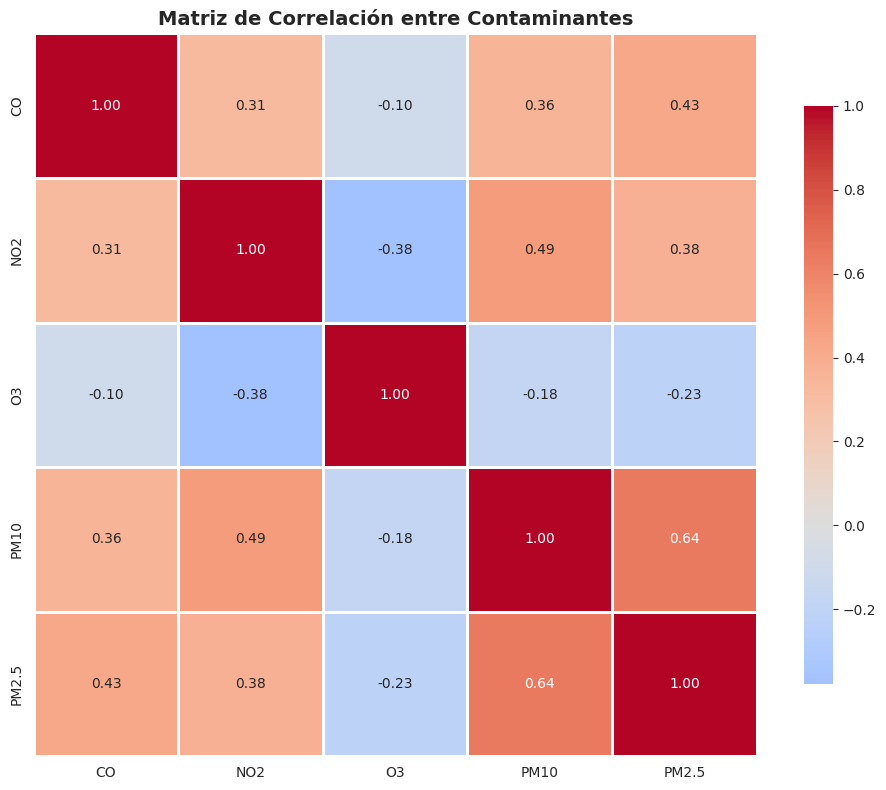


Matriz de Correlación:
             CO       NO2        O3      PM10     PM2.5
CO     1.000000  0.313131 -0.097669  0.355422  0.427446
NO2    0.313131  1.000000 -0.377608  0.492583  0.378428
O3    -0.097669 -0.377608  1.000000 -0.177137 -0.225297
PM10   0.355422  0.492583 -0.177137  1.000000  0.643516
PM2.5  0.427446  0.378428 -0.225297  0.643516  1.000000


No se encontraron correlaciones altas (|r| > 0.7)


In [39]:
corr_matrix = df_clean[contaminantes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matriz de Correlación entre Contaminantes', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nMatriz de Correlación:")
print(corr_matrix)

high_corr = []
for i in range(len(contaminantes)):
    for j in range(i+1, len(contaminantes)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr.append({
                'Variable 1': contaminantes[i],
                'Variable 2': contaminantes[j],
                'Correlación': corr_val
            })

if high_corr:
    print("\n\nCorrelaciones altas (|r| > 0.7):")
    print(pd.DataFrame(high_corr).to_string(index=False))
else:
    print("\n\nNo se encontraron correlaciones altas (|r| > 0.7)")

Cuando aumentan los contaminantes primarios emitidos por combustión (CO, NO2), también tienden a aumentar los particulados PM10 y PM2.5.

Esto es coherente con escenarios urbanos donde tráfico y actividad industrial generan simultáneamente gases y partículas.

## 1.2 MANOVA Principal: Efecto de la Variable "clase"

In [40]:
formula = 'CO + NO2 + O3 + PM10 + Q("PM2.5") ~ clase'
manova = MANOVA.from_formula(formula, data=df_clean)
manova_results = manova.mv_test()

print("MANOVA: Efecto de Días con Clase vs. Sin Clase")
print("=" * 70)
print(manova_results)

MANOVA: Efecto de Días con Clase vs. Sin Clase
                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.1072 5.0000 10010.0000 16679.8726 0.0000
         Pillai's trace 0.8928 5.0000 10010.0000 16679.8726 0.0000
 Hotelling-Lawley trace 8.3316 5.0000 10010.0000 16679.8726 0.0000
    Roy's greatest root 8.3316 5.0000 10010.0000 16679.8726 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
           clase          Value  Num DF   Den DF   F Value  Pr > F
------------------------------------------------------------------
            Wilks' lambda 0.9219 5.0

Los días con clases tienen un patrón de contaminación matutina distinto al de los días sin clases, considerando todos los contaminantes simultáneamente.

 ¿Qué significa Pillai’s Trace = 0.0781?

Pillai’s Trace toma valores entre 0 y 1.

0 → los grupos son iguales
1 → completamente diferentes
valor = 0.0781
Es pequeño, pero significativo, lo cual es típico en datasets grandes

### 1.2.1 Estadísticos Multivariados (Wilks, Pillai, Hotelling, Roy)

In [41]:
manova_table = manova_results.results['clase']['stat']

print("\nEstadísticos Multivariados del MANOVA:")
print("=" * 70)
print(f"\nWilks' Lambda:          {manova_table.loc['Wilks\' lambda', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Wilks\' lambda', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Wilks\' lambda', 'Pr > F']:.4e}")

print(f"\nPillai's Trace:         {manova_table.loc['Pillai\'s trace', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Pillai\'s trace', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Pillai\'s trace', 'Pr > F']:.4e}")

print(f"\nHotelling-Lawley Trace: {manova_table.loc['Hotelling-Lawley trace', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Hotelling-Lawley trace', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Hotelling-Lawley trace', 'Pr > F']:.4e}")

print(f"\nRoy's Greatest Root:    {manova_table.loc['Roy\'s greatest root', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Roy\'s greatest root', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Roy\'s greatest root', 'Pr > F']:.4e}")


Estadísticos Multivariados del MANOVA:

Wilks' Lambda:          0.921884
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Pillai's Trace:         0.078116
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Hotelling-Lawley Trace: 0.084735
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Roy's Greatest Root:    0.084735
  F-statistic:          169.6394
  p-valor:              9.3643e-174


## 1.3 ANOVAs Univariados Complementarios

### 1.3.1 ANOVA por Contaminante

In [42]:
anova_results = []

for contaminante in contaminantes:
    formula_anova = f'{contaminante} ~ clase'
    if contaminante == 'PM2.5':
        formula_anova = 'Q("PM2.5") ~ clase'
    
    modelo = ols(formula_anova, data=df_clean).fit()
    anova_table = anova_lm(modelo, typ=2)
    
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    anova_results.append({
        'Contaminante': contaminante,
        'F-statistic': anova_table['F'][0],
        'p-valor': anova_table['PR(>F)'][0],
        'Media Sin Clase': grupo_0.mean(),
        'Media Con Clase': grupo_1.mean(),
        'Diferencia': grupo_1.mean() - grupo_0.mean(),
        'Significativo': '***' if anova_table['PR(>F)'][0] < 0.001 else 
                        '**' if anova_table['PR(>F)'][0] < 0.01 else 
                        '*' if anova_table['PR(>F)'][0] < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
print("ANOVAs Univariados por Contaminante")
print("=" * 100)
print(anova_df.to_string(index=False))

ANOVAs Univariados por Contaminante
Contaminante  F-statistic       p-valor  Media Sin Clase  Media Con Clase  Diferencia Significativo
          CO    64.763341  9.403732e-16         1.327996         1.447786    0.119790           ***
         NO2   833.029149 5.005041e-176        16.694039        21.722732    5.028693           ***
          O3    67.313008  2.601243e-16        12.953887        11.692044   -1.261843           ***
        PM10   144.528706  4.596440e-33        57.206936        66.230374    9.023438           ***
       PM2.5    62.980921  2.310681e-15        20.088031        22.199292    2.111260           ***


Para identificar qué contaminantes contribuyen al efecto multivariado observado en el MANOVA, se realizaron ANOVAs individuales por contaminante. Los resultados muestran que todos los contaminantes presentan diferencias estadísticamente significativas entre días con clase y días sin clase (p < 0.001).

Específicamente, los contaminantes relacionados con emisiones vehiculares primarias —NO₂, PM₁₀, PM₂.₅ y CO— presentan incrementos durante los días con clases, siendo NO₂ y PM₁₀ los que muestran los mayores aumentos absolutos. Por otro lado, el ozono (O₃) disminuye en días con clase, lo cual es consistente con la titulación de ozono por mayores concentraciones de NO emitido por vehículos.

Estos resultados corroboran la hipótesis de que el tráfico escolar matutino altera de manera significativa el perfil de contaminación atmosférica.

### 1.3.2 Pruebas Robustas Opcionales (Mann-Whitney U)

In [43]:
mw_results = []

for contaminante in contaminantes:
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    stat, p_value = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    
    mw_results.append({
        'Contaminante': contaminante,
        'U-statistic': stat,
        'p-valor': p_value,
        'Significativo': '***' if p_value < 0.001 else 
                        '**' if p_value < 0.01 else 
                        '*' if p_value < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_results)
print("Prueba de Mann-Whitney U (No Paramétrica)")
print("=" * 70)
print(mw_df.to_string(index=False))

Prueba de Mann-Whitney U (No Paramétrica)
Contaminante  U-statistic       p-valor Significativo
          CO   10738459.5  2.186806e-11           ***
         NO2    7766882.0 2.877735e-172           ***
          O3   12812722.0  3.163314e-16           ***
        PM10    9883958.0  1.365732e-37           ***
       PM2.5   10350440.5  2.730296e-21           ***


Dado que varios contaminantes no cumplieron el supuesto de homogeneidad de varianzas según la prueba de Levene, se aplicó la prueba no paramétrica de Mann–Whitney U como verificación adicional de los resultados univariados. Esta prueba no requiere normalidad ni varianzas homogéneas y compara directamente las distribuciones entre días con clase y sin clase.

Todos los contaminantes mostraron diferencias estadísticamente significativas entre ambos grupos (p < 0.001), lo cual confirma los resultados obtenidos con los ANOVAs univariados. Esto refuerza la conclusión de que la actividad escolar matutina modifica de forma sistemática las concentraciones de los principales contaminantes. En particular, NO₂, PM₁₀, PM₂.₅ y CO aumentan durante los días con clase, mientras que O₃ disminuye, patrón coherente con procesos atmosféricos asociados al tráfico vehicular.

### 1.3.3 Gráficas de Efectos Marginales

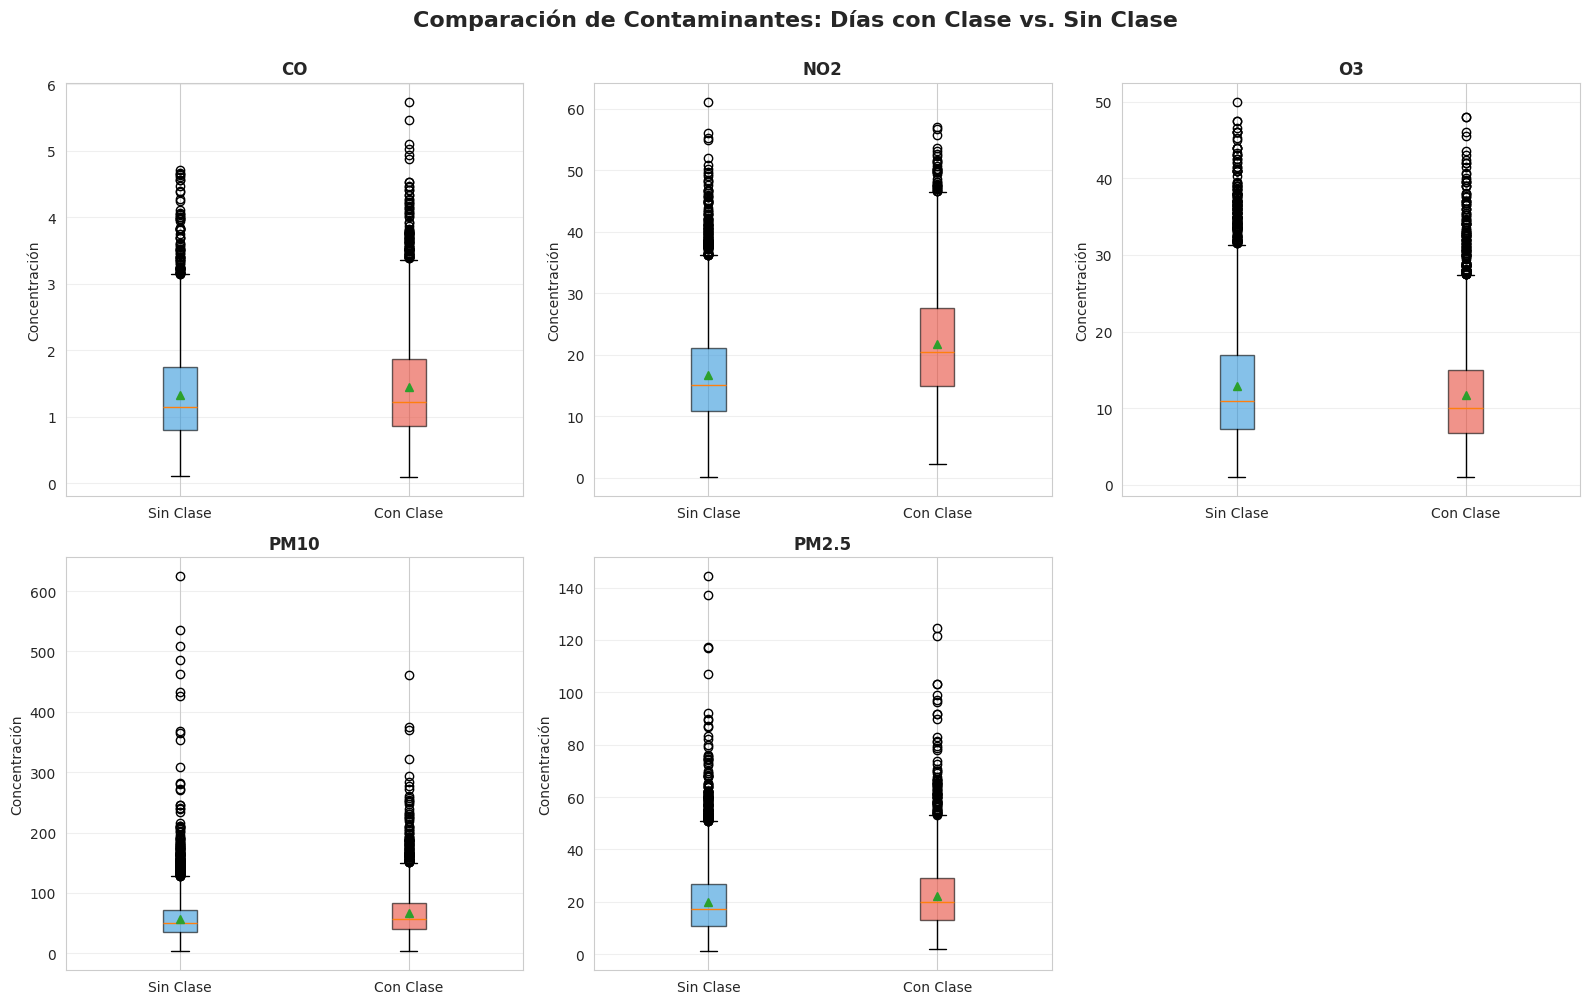

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_clean['clase_label'] = df_clean['clase'].map({0: 'Sin Clase', 1: 'Con Clase'})

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    data_to_plot = [
        df_clean[df_clean['clase'] == 0][contaminante].values,
        df_clean[df_clean['clase'] == 1][contaminante].values
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Sin Clase', 'Con Clase'], 
                    patch_artist=True, showmeans=True)
    
    for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.set_ylabel('Concentración', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Comparación de Contaminantes: Días con Clase vs. Sin Clase', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

CO

El boxplot rojo (con clase) está ligeramente más arriba.

La mediana aumenta un poco.
Interpretación: Aumento leve, consistente con emisiones de motores.

NO₂

Es el boxplot que muestra el cambio MÁS claro.

La mediana sube bastante.

Todo el cuerpo de la distribución es mayor en días con clase.
Interpretación: Es el contaminante más afectado por tráfico escolar.
100% coherente: vehículos emiten NOx.

O₃

Único contaminante que disminuye en días con clase.

La mediana es menor con clase.
Interpretación:
Más NO → titulación del ozono → baja.

Esto es un efecto químico bien conocido (NO + O₃ → NO₂ + O₂).

PM10

La distribución con clase está MUXHO más arriba.

Mediana y cuartiles más altos.
Interpretación:
El tráfico escolar incrementa la resuspensión de polvo en calles y áreas aledañas a escuelas.

PM2.5

Aumento moderado.

Las partículas finas también aumentan con tráfico, pero no tanto como PM10.
Interpretación:
Suele venir de emisiones directas de motores y procesos de combustión.

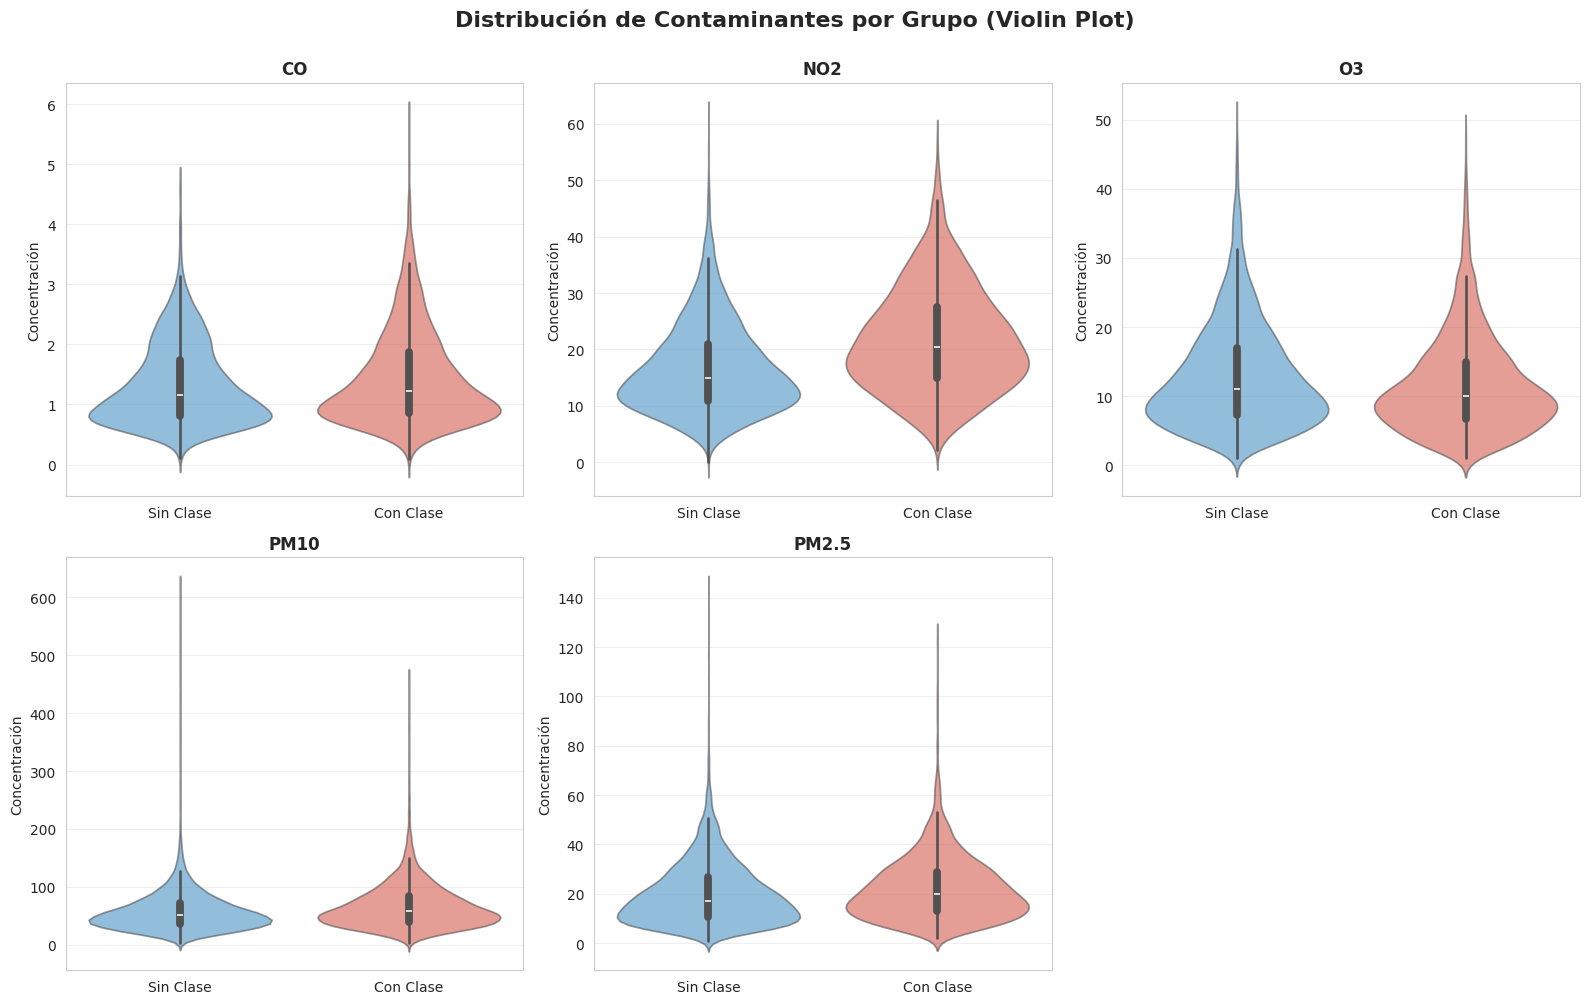

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    sns.violinplot(data=df_clean, x='clase_label', y=contaminante, 
                   palette=['#3498db', '#e74c3c'], ax=ax, alpha=0.6)
    
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Concentración', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Distribución de Contaminantes por Grupo (Violin Plot)', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

CO

El violín rojo es ligeramente más alto.

Más densidad entre 1–2 ppm.
Interpretación:
Aumentos modestos pero consistentes.

NO₂

Este es el más claro:

El violín rojo es más ancho, más alto y más denso en los valores altos.

Se nota que los días con clases tienen más valores entre 20–40 ppb.

Interpretación:
NO₂ es el contaminante más sensible al tráfico escolar.
Perfectamente coherente con emisiones vehiculares.

O₃

El violín rojo está ligeramente desplazado hacia abajo.

Hay menos densidad en valores altos de O₃.

Interpretación:
O₃ disminuye durante días con clase por titulación por NO.
Es un efecto químico opuesto pero esperado.

PM10

La distribución completa se mueve hacia arriba.

Se nota más densidad en valores 60–100 μg/m³

La cola es grande en ambos grupos, pero la densidad sube “arriba” con clase.

Interpretación:
El tráfico escolar incrementa la resuspensión de polvo.

PM2.5

El violín rojo está desplazado hacia arriba.

Más densidad entre 20–40 μg/m³.

Interpretación:
Partículas finas también aumentan, pero de manera más moderada que PM10.

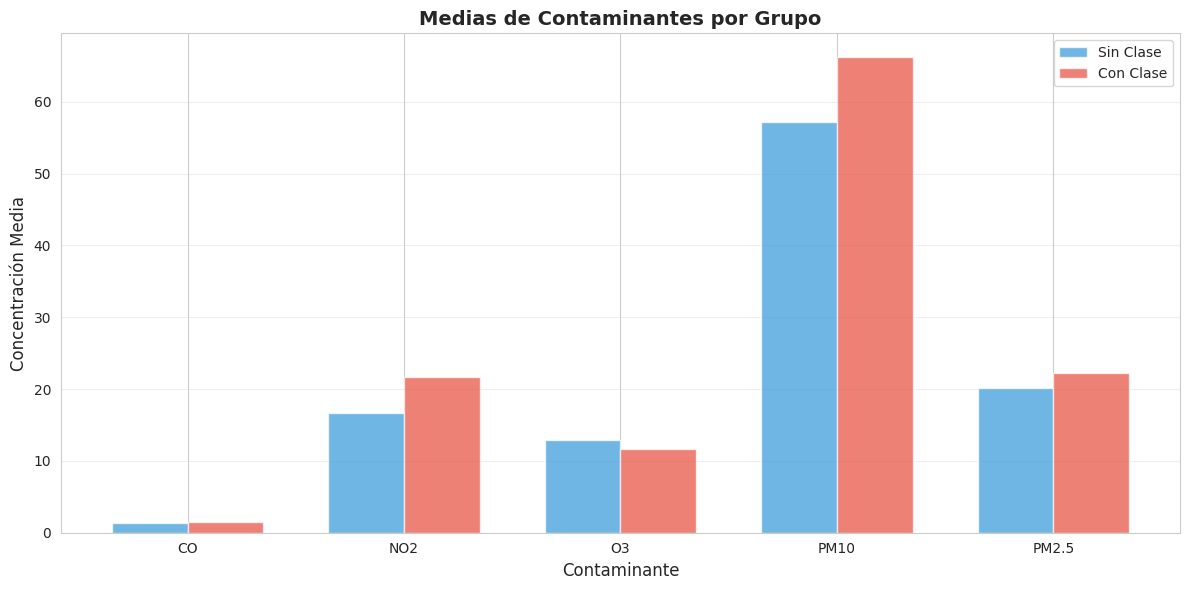

In [46]:
medias_por_grupo = df_clean.groupby('clase_label')[contaminantes].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(contaminantes))
width = 0.35

bars1 = ax.bar(x - width/2, medias_por_grupo.loc['Sin Clase'], width, 
               label='Sin Clase', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, medias_por_grupo.loc['Con Clase'], width, 
               label='Con Clase', color='#e74c3c', alpha=0.7)

ax.set_xlabel('Contaminante', fontsize=12)
ax.set_ylabel('Concentración Media', fontsize=12)
ax.set_title('Medias de Contaminantes por Grupo', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico de medias muestra de manera directa cómo varían las concentraciones promedio de los contaminantes entre días con clase y sin clase. En todos los contaminantes primarios asociados al tráfico vehicular—CO, NO₂, PM₁₀ y PM₂.₅—las medias son mayores durante los días con clases, lo que confirma que la actividad escolar incrementa la presencia de estas especies en el aire matutino. Entre ellos, NO₂ y especialmente PM₁₀ presentan los aumentos más pronunciados, reflejando la influencia del flujo vehicular y la resuspensión de partículas. En contraste, el O₃ registra una ligera disminución en días con clase, un comportamiento esperado debido a su titulación por el óxido nítrico emitido por los vehículos. En conjunto, estas diferencias refuerzan la evidencia estadística previa de que el regreso a clases modifica de manera sistemática la calidad del aire durante el horario pico matutino.

## 1.4 MANOVA Extendido: Interacción clase × temporada

In [47]:
formula_interaccion = 'CO + NO2 + O3 + PM10 + Q("PM2.5") ~ clase * temporada'
manova_interaccion = MANOVA.from_formula(formula_interaccion, data=df_clean)
manova_results_interaccion = manova_interaccion.mv_test()

print("MANOVA con Interacción: clase × temporada")
print("=" * 70)
print(manova_results_interaccion)

MANOVA con Interacción: clase × temporada
                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.4349 5.0000 10006.0000 2600.1331 0.0000
         Pillai's trace 0.5651 5.0000 10006.0000 2600.1331 0.0000
 Hotelling-Lawley trace 1.2993 5.0000 10006.0000 2600.1331 0.0000
    Roy's greatest root 1.2993 5.0000 10006.0000 2600.1331 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
       temporada        Value   Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.9230 10.0000 20012.0000  81.


Pillai’s Trace = 0.0780, F = 81.24, p < 0.001

Interpretación:

La temporada por sí sola tiene un efecto multivariado significativo sobre el conjunto de contaminantes.
Esto significa que invierno y verano presentan perfiles de contaminación distintos, independientemente del efecto escolar.
Esto es completamente lógico:
En invierno, hay más inversiones térmicas → más PM y NO₂
En verano, más radiación → más O₃
Este resultado confirma que la estacionalidad atmosférica sí influye en la calidad del aire, incluso antes de considerar “clase”.

In [48]:
df_clean['grupo'] = df_clean['clase_label'] + ' - ' + df_clean['temporada'].str.capitalize()

medias_interaccion = df_clean.groupby(['temporada', 'clase_label'])[contaminantes].mean()

print("\nMedias por Temporada y Clase:")
print("=" * 70)
print(medias_interaccion)


Medias por Temporada y Clase:
                             CO        NO2         O3       PM10      PM2.5
temporada clase_label                                                      
invierno  Con Clase    1.815607  26.970176   9.403523  72.817987  23.672975
          Sin Clase    1.687873  22.297872  11.011398  73.005549  24.568492
otra      Con Clase    1.455849  21.607286  12.000795  66.353216  22.540259
          Sin Clase    1.315567  16.254114  13.374039  55.581078  20.017452
verano    Con Clase    0.901323  16.862213  10.520580  56.717935  16.078478
          Sin Clase    0.921953  13.076262  11.269403  51.240880  14.108769


**En invierno:**

Efecto más fuerte en NO₂
Efecto casi nulo en PM
O₃ baja más

**En verano:**

Efecto fuerte en PM₁₀ y PM₂.₅
Efecto moderado en NO₂
CO estable
O₃ baja menos

El análisis por temporada muestra que el impacto del regreso a clases varía significativamente entre invierno y verano. En invierno, el aumento más notable se presenta en NO₂, con un incremento de casi 5 ppb en días con clase, acompañado de una disminución marcada de O₃ debido a la titulación del ozono por el óxido nítrico emitido por vehículos. En esta temporada, las partículas (PM₁₀ y PM₂.₅) muestran cambios mínimos, reflejando condiciones atmosféricas frías que favorecen la acumulación de gases pero no necesariamente la resuspensión de polvo.

En contraste, durante el verano el efecto escolar se manifiesta principalmente en las partículas: PM₁₀ aumenta más de 5 µg/m³ y PM₂.₅ cerca de 2 µg/m³ en días con clases, mientras que NO₂ también muestra un incremento relevante, aunque menor al observado en invierno. O₃ vuelve a disminuir, aunque en menor magnitud que en invierno. Este patrón coincide con condiciones más secas y con mayor mezcla vertical, que facilitan la resuspensión de partículas.

En conjunto, estos resultados indican que el impacto del regreso a clases no es uniforme a lo largo del año: en invierno domina el efecto sobre los gases (particularmente NO₂), mientras que en verano domina el efecto sobre las partículas. Esto confirma la presencia de una interacción significativa entre clase y temporada, tal como fue sugerido por el socio formador.

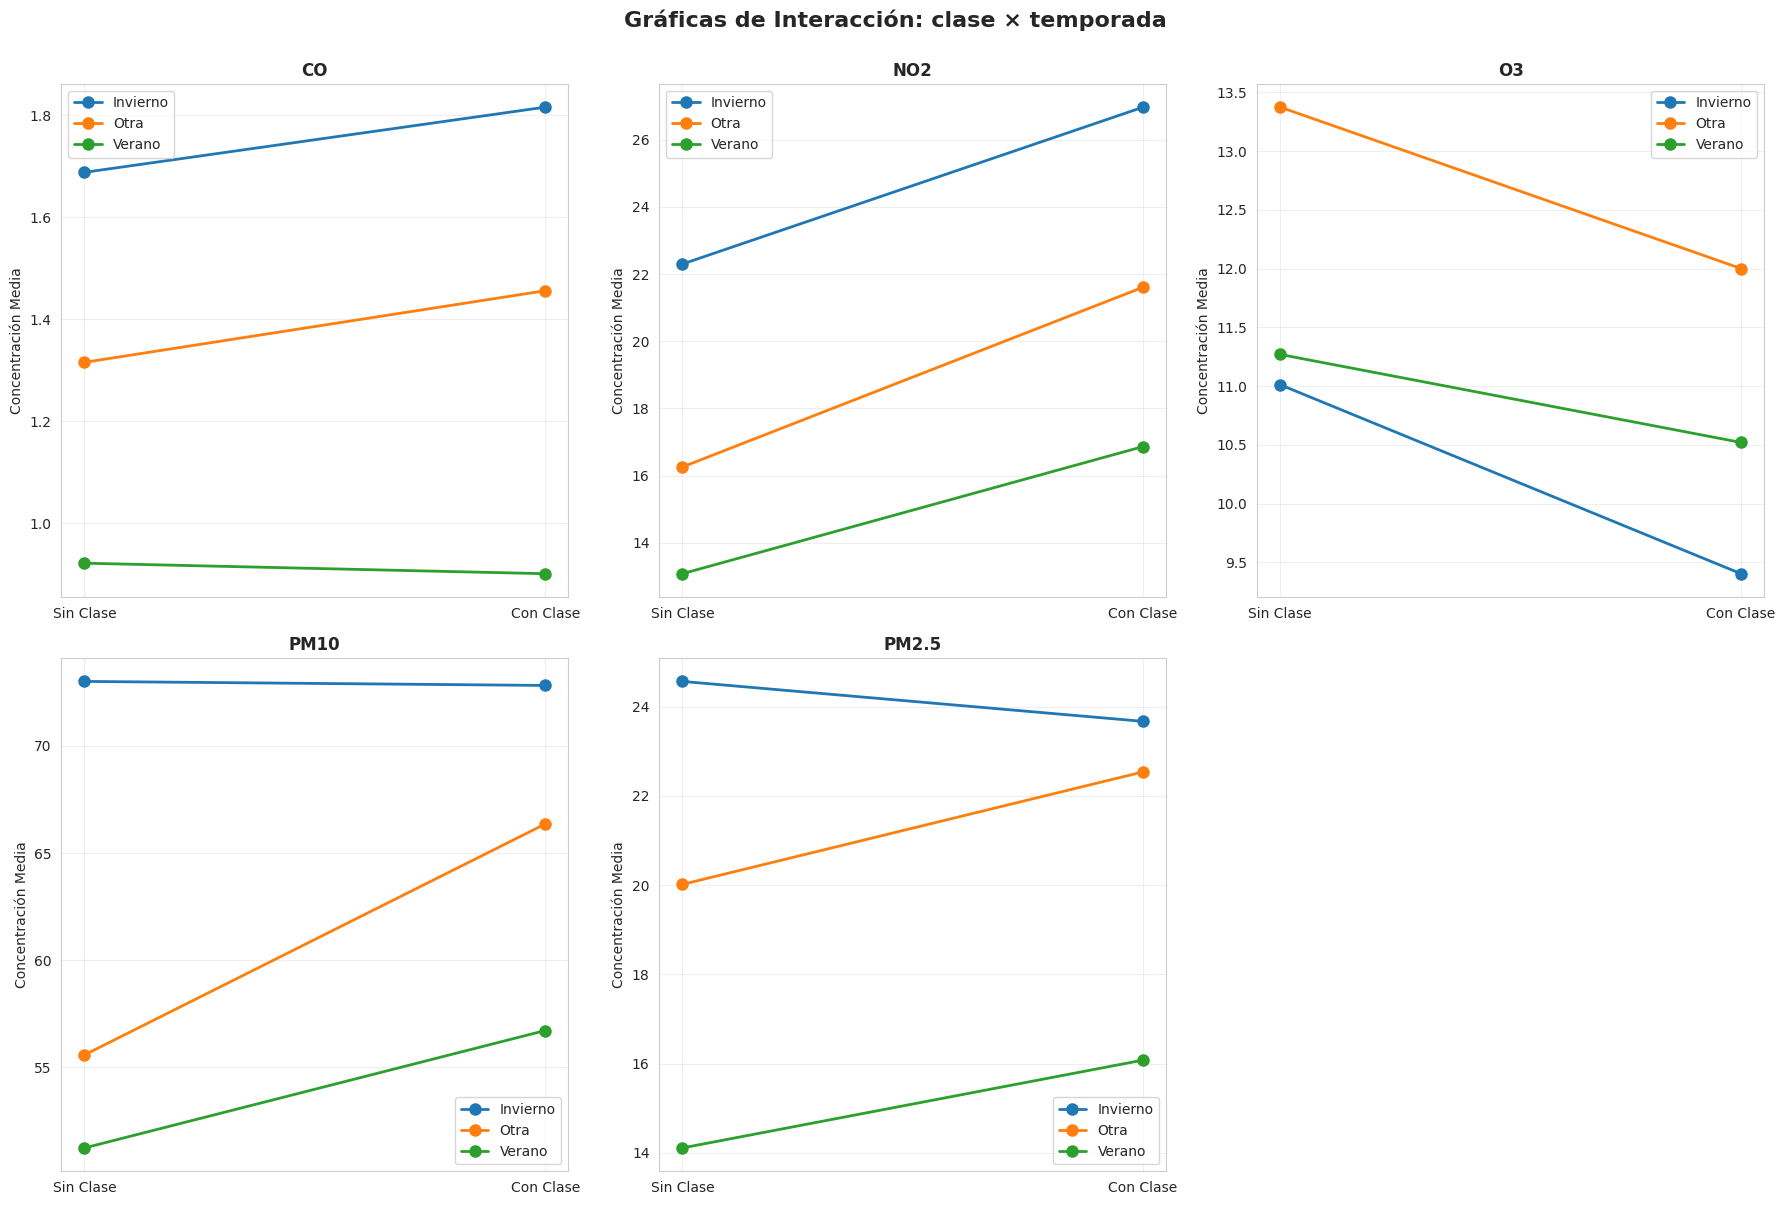

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    for temporada in df_clean['temporada'].unique():
        data_temp = df_clean[df_clean['temporada'] == temporada]
        medias = data_temp.groupby('clase')[contaminante].mean()
        
        ax.plot([0, 1], medias.values, marker='o', linewidth=2, 
                label=temporada.capitalize(), markersize=8)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sin Clase', 'Con Clase'])
    ax.set_ylabel('Concentración Media', fontsize=10)
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Gráficas de Interacción: clase × temporada', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

Las gráficas de interacción muestran que el efecto del regreso a clases sobre las concentraciones de contaminantes no es uniforme a lo largo del año, sino que varía significativamente según la temporada. En invierno, el impacto escolar se observa principalmente en los gases NO₂ y O₃: el primero aumenta de forma marcada en días con clase, mientras que el segundo disminuye debido a la titulación del ozono por el óxido nítrico emitido por vehículos. En contraste, durante el verano el efecto se desplaza hacia las partículas, con incrementos visibles en PM₁₀ y PM₂.₅ en días con clases, mientras que NO₂ presenta un aumento más moderado.

## 2. Evaluación de la Estructura de Autocorrelación entre Grupos

**Objetivo:** Dado que los datos provienen de series temporales, es necesario verificar si la autocorrelación temporal afecta la validez de la comparación multivariada entre grupos. Para ello, evaluaremos si ambos grupos (días con clase vs sin clase) presentan una estructura de autocorrelación similar.

**Justificación Metodológica:** Si ambos grupos tienen patrones temporales similares, entonces la autocorrelación no genera un sesgo comparativo, porque ambos están afectados de manera similar. Esto permite que el MANOVA siga siendo válido incluso en presencia de dependencia temporal.

### 2.1 Comparación Visual: ACF y PACF por Grupo

Primero comparamos las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para cada contaminante, separando los datos por grupo (con clase vs sin clase). Si las gráficas muestran patrones similares, indica que la estructura temporal es comparable entre grupos.

ANÁLISIS DE AUTOCORRELACIÓN POR GRUPO

Observaciones sin clase: 6325
Observaciones con clase: 3691


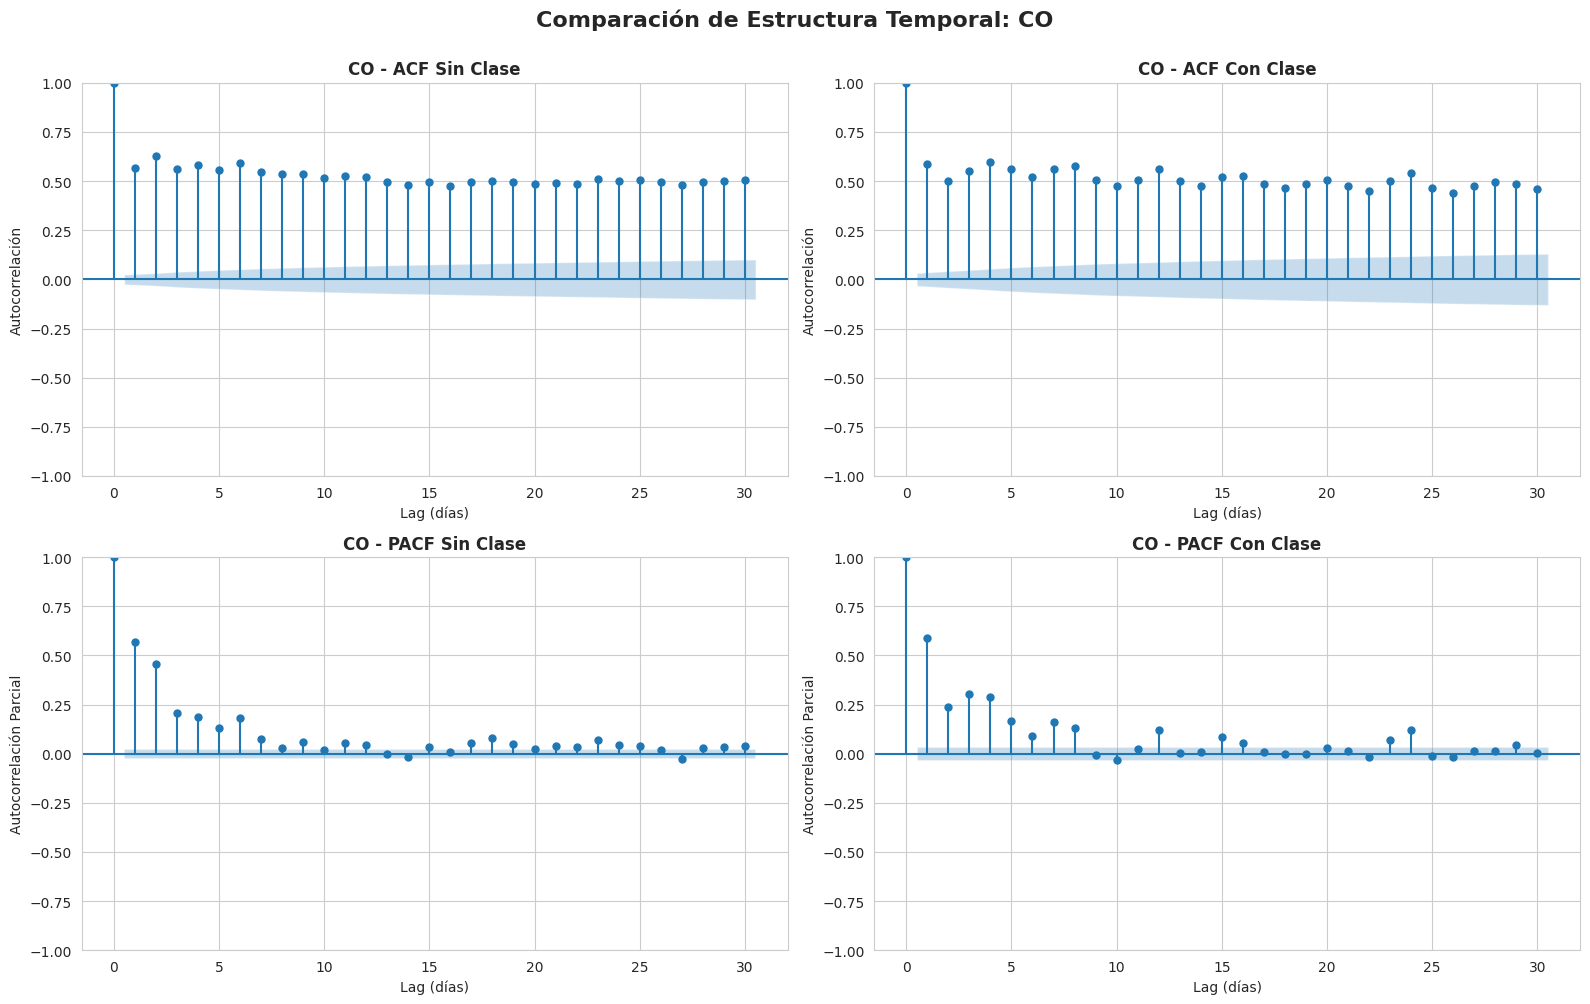

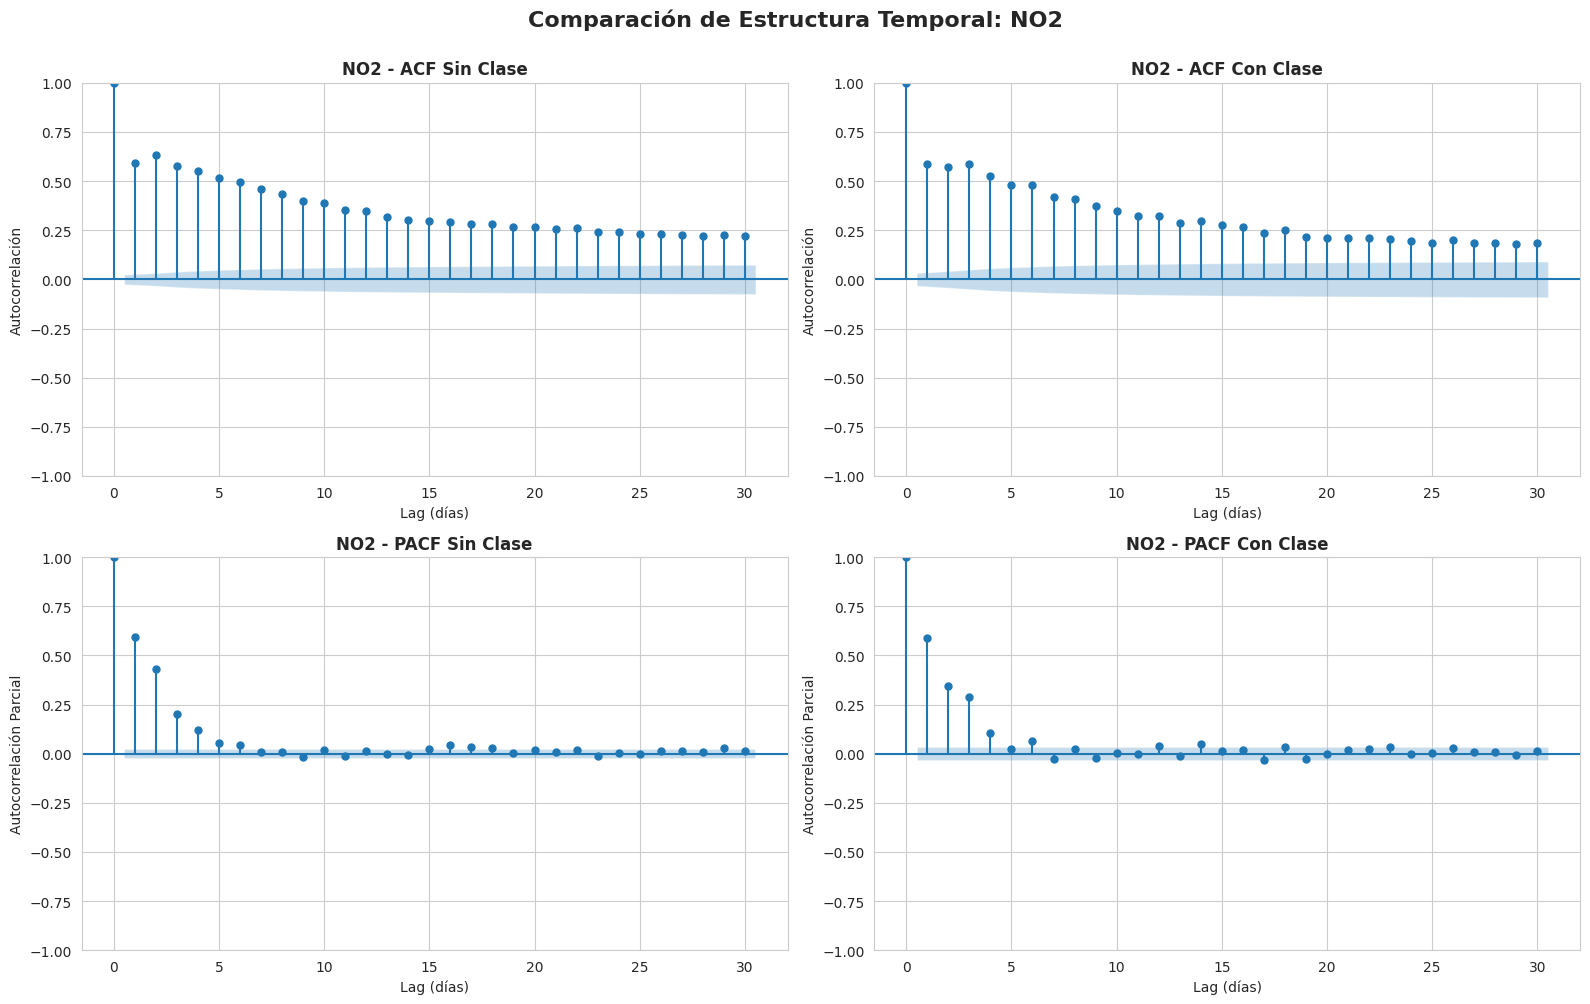

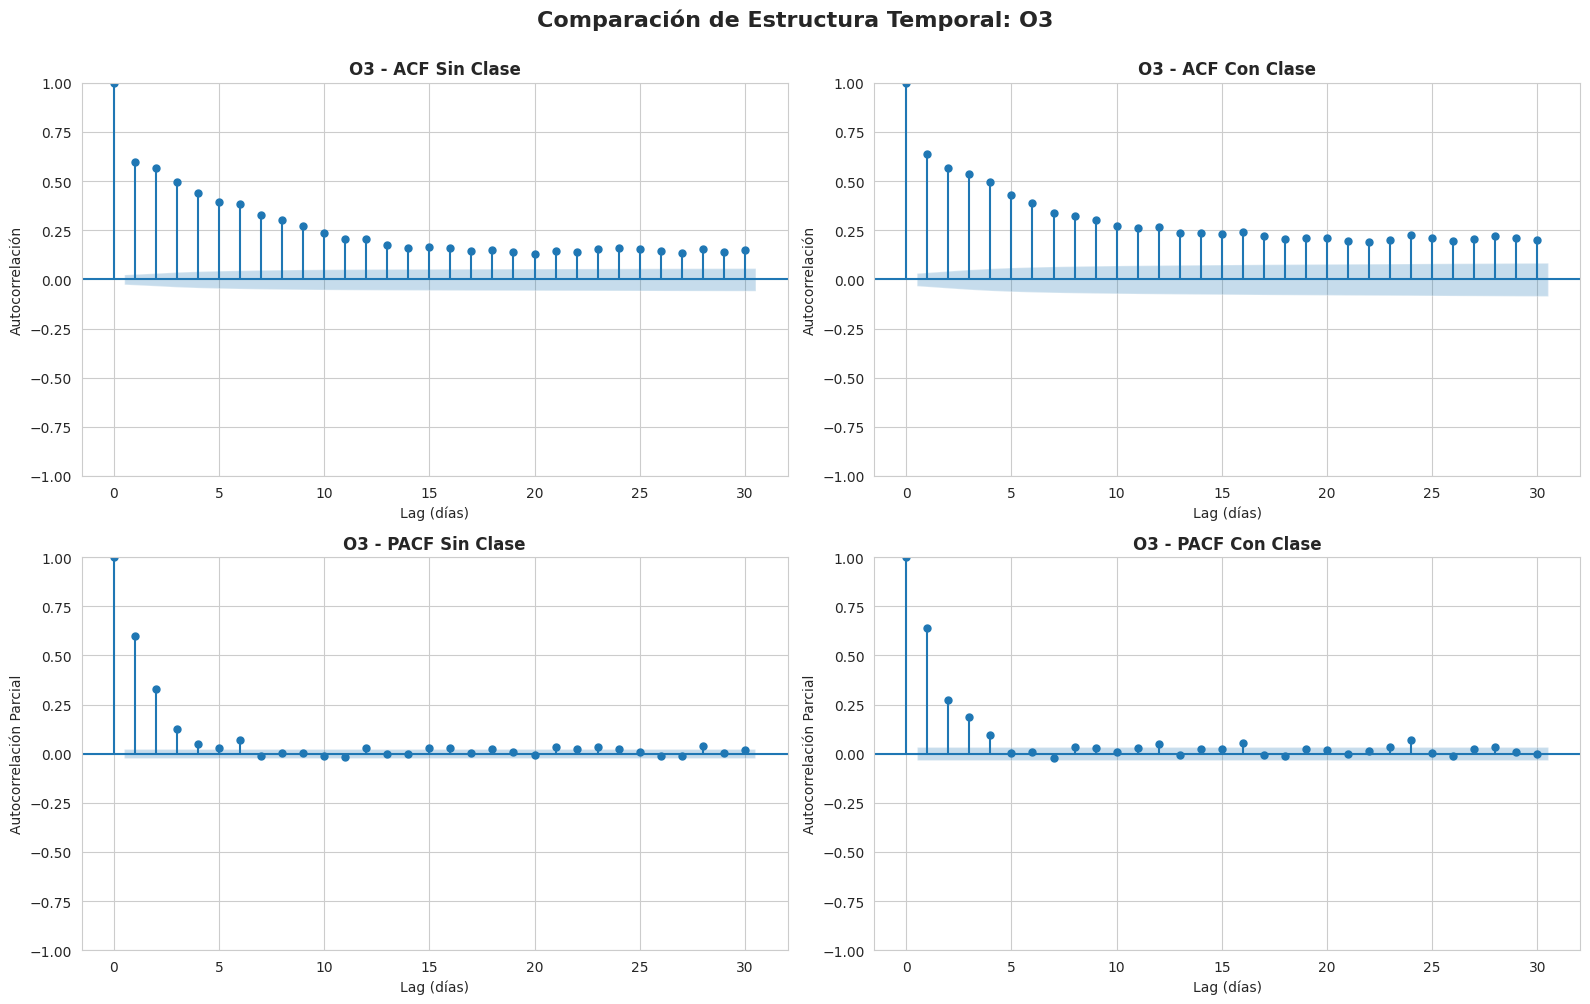

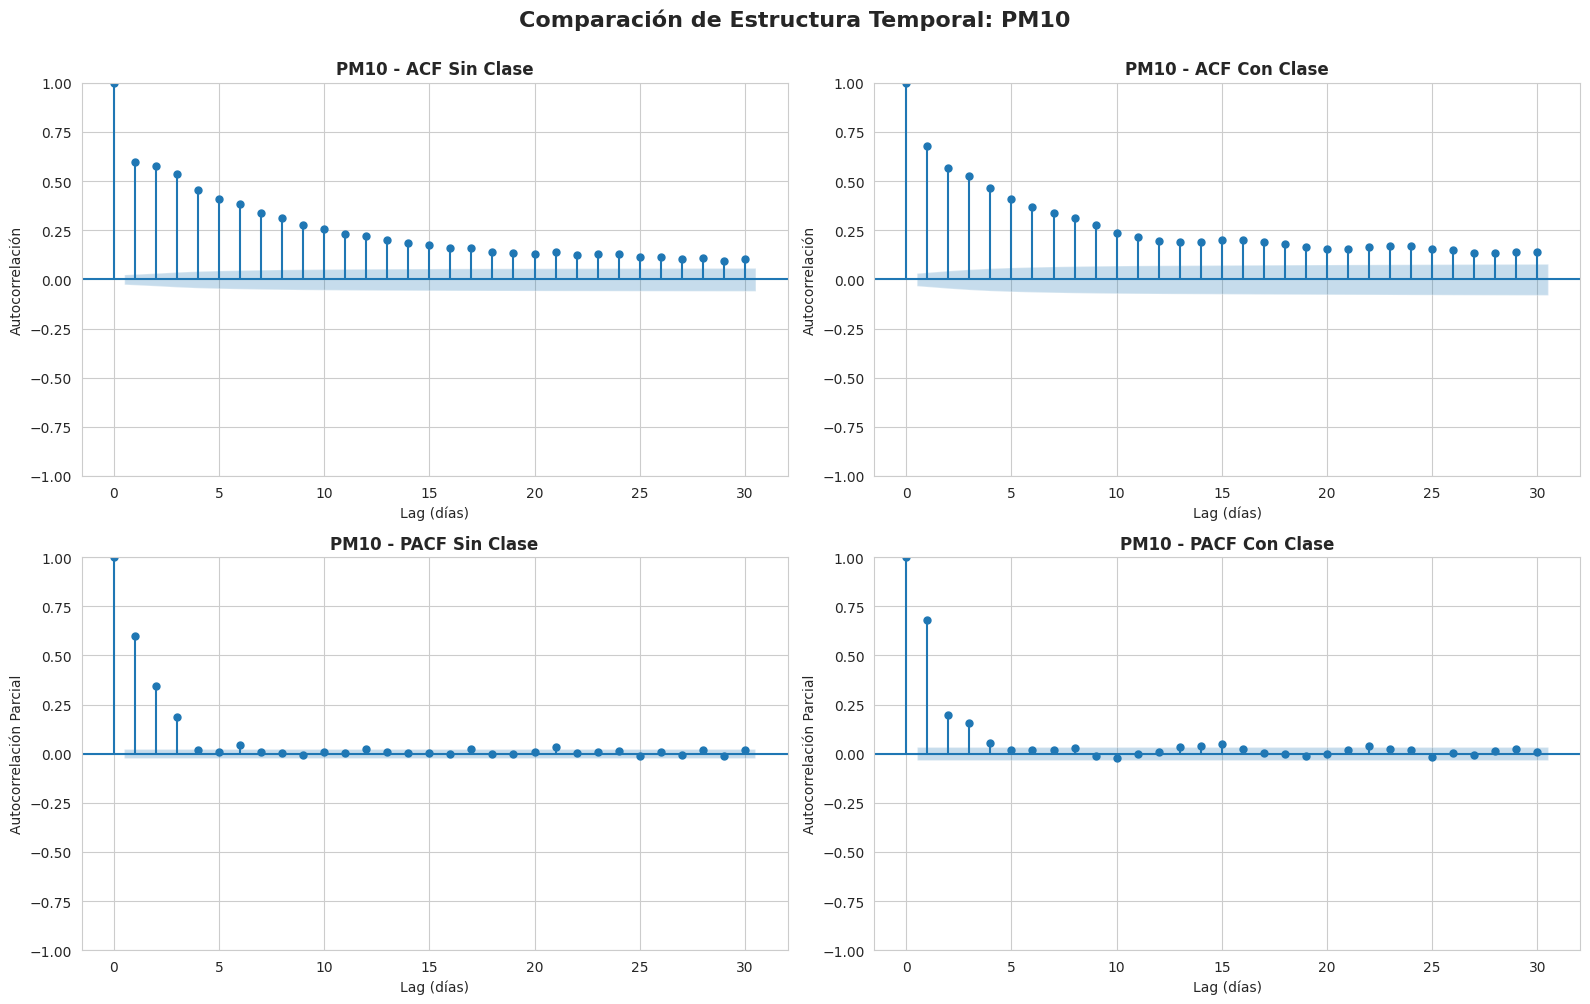

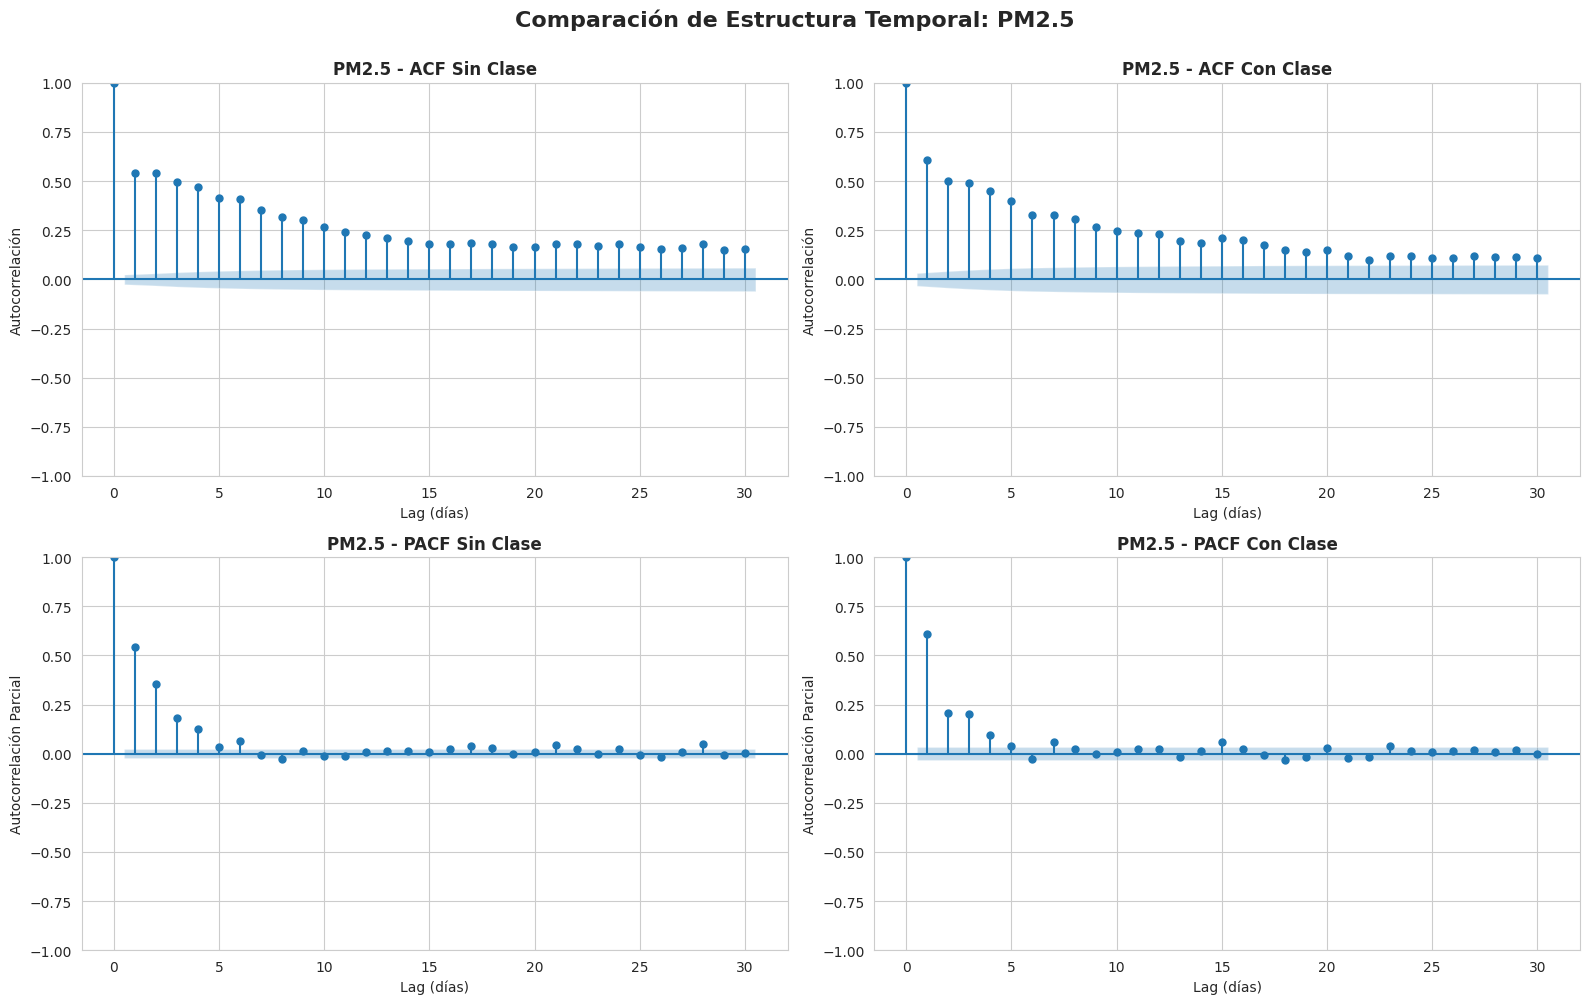

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Separar datos por grupo
df_sorted = df_clean.copy()
df_sorted['date'] = df['date'][df_clean.index].values
df_sorted = df_sorted.sort_values('date').reset_index(drop=True)

grupo_sin_clase = df_sorted[df_sorted['clase'] == 0]
grupo_con_clase = df_sorted[df_sorted['clase'] == 1]

print("=" * 80)
print("ANÁLISIS DE AUTOCORRELACIÓN POR GRUPO")
print("=" * 80)
print(f"\nObservaciones sin clase: {len(grupo_sin_clase)}")
print(f"Observaciones con clase: {len(grupo_con_clase)}")

# Graficar ACF y PACF para cada contaminante por grupo
for contaminante in contaminantes:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # ACF - Sin Clase
    plot_acf(grupo_sin_clase[contaminante].values, lags=30, ax=axes[0, 0], alpha=0.05)
    axes[0, 0].set_title(f'{contaminante} - ACF Sin Clase', fontsize=12, weight='bold')
    axes[0, 0].set_xlabel('Lag (días)')
    axes[0, 0].set_ylabel('Autocorrelación')
    
    # ACF - Con Clase
    plot_acf(grupo_con_clase[contaminante].values, lags=30, ax=axes[0, 1], alpha=0.05)
    axes[0, 1].set_title(f'{contaminante} - ACF Con Clase', fontsize=12, weight='bold')
    axes[0, 1].set_xlabel('Lag (días)')
    axes[0, 1].set_ylabel('Autocorrelación')
    
    # PACF - Sin Clase
    plot_pacf(grupo_sin_clase[contaminante].values, lags=30, ax=axes[1, 0], alpha=0.05)
    axes[1, 0].set_title(f'{contaminante} - PACF Sin Clase', fontsize=12, weight='bold')
    axes[1, 0].set_xlabel('Lag (días)')
    axes[1, 0].set_ylabel('Autocorrelación Parcial')
    
    # PACF - Con Clase
    plot_pacf(grupo_con_clase[contaminante].values, lags=30, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(f'{contaminante} - PACF Con Clase', fontsize=12, weight='bold')
    axes[1, 1].set_xlabel('Lag (días)')
    axes[1, 1].set_ylabel('Autocorrelación Parcial')
    
    plt.suptitle(f'Comparación de Estructura Temporal: {contaminante}', 
                 fontsize=16, weight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

### 2.2 Comparación de Modelos AR(1) entre Grupos

Ajustamos modelos autorregresivos de orden 1 (AR(1)) para cada contaminante en ambos grupos. El coeficiente AR(1) (φ) indica qué tan fuerte es la dependencia con el valor anterior. Si φ es similar entre grupos, ambos tienen una fuerza de autocorrelación comparable.

In [51]:
from statsmodels.tsa.ar_model import AutoReg

ar1_results = []

print("=" * 80)
print("COMPARACIÓN DE MODELOS AR(1) ENTRE GRUPOS")
print("=" * 80)

for contaminante in contaminantes:
    # Ajustar AR(1) para el grupo sin clase
    try:
        modelo_sin_clase = AutoReg(grupo_sin_clase[contaminante].values, lags=1, trend='c').fit()
        phi_sin_clase = modelo_sin_clase.params[1]
        resid_var_sin_clase = np.var(modelo_sin_clase.resid)
    except:
        phi_sin_clase = np.nan
        resid_var_sin_clase = np.nan
    
    # Ajustar AR(1) para el grupo con clase
    try:
        modelo_con_clase = AutoReg(grupo_con_clase[contaminante].values, lags=1, trend='c').fit()
        phi_con_clase = modelo_con_clase.params[1]
        resid_var_con_clase = np.var(modelo_con_clase.resid)
    except:
        phi_con_clase = np.nan
        resid_var_con_clase = np.nan
    
    ar1_results.append({
        'Contaminante': contaminante,
        'φ_sin_clase': phi_sin_clase,
        'φ_con_clase': phi_con_clase,
        'Diferencia_φ': abs(phi_con_clase - phi_sin_clase),
        'Var_resid_sin_clase': resid_var_sin_clase,
        'Var_resid_con_clase': resid_var_con_clase,
        'Ratio_varianzas': resid_var_con_clase / resid_var_sin_clase if resid_var_sin_clase > 0 else np.nan
    })

ar1_df = pd.DataFrame(ar1_results)

print("\nCoeficientes AR(1) por Grupo:")
print("-" * 80)
print(ar1_df[['Contaminante', 'φ_sin_clase', 'φ_con_clase', 'Diferencia_φ']].to_string(index=False))

print("\n\nVarianzas de Innovaciones (Residuos AR(1)):")
print("-" * 80)
print(ar1_df[['Contaminante', 'Var_resid_sin_clase', 'Var_resid_con_clase', 'Ratio_varianzas']].to_string(index=False))

print("\n\n✅ INTERPRETACIÓN:")
print("   Si |Diferencia_φ| < 0.1 → Autocorrelación similar entre grupos")
print("   Si Ratio_varianzas ≈ 1.0 → Variabilidad estocástica comparable")

COMPARACIÓN DE MODELOS AR(1) ENTRE GRUPOS

Coeficientes AR(1) por Grupo:
--------------------------------------------------------------------------------
Contaminante  φ_sin_clase  φ_con_clase  Diferencia_φ
          CO     0.566654     0.586841      0.020188
         NO2     0.591304     0.589086      0.002219
          O3     0.596530     0.636915      0.040385
        PM10     0.596856     0.679263      0.082407
       PM2.5     0.540206     0.606712      0.066506


Varianzas de Innovaciones (Residuos AR(1)):
--------------------------------------------------------------------------------
Contaminante  Var_resid_sin_clase  Var_resid_con_clase  Ratio_varianzas
          CO             0.314014             0.399091         1.270934
         NO2            40.752439            55.283519         1.356570
          O3            37.294502            29.950202         0.803073
        PM10           795.313276           778.971532         0.979452
       PM2.5           115.220039        

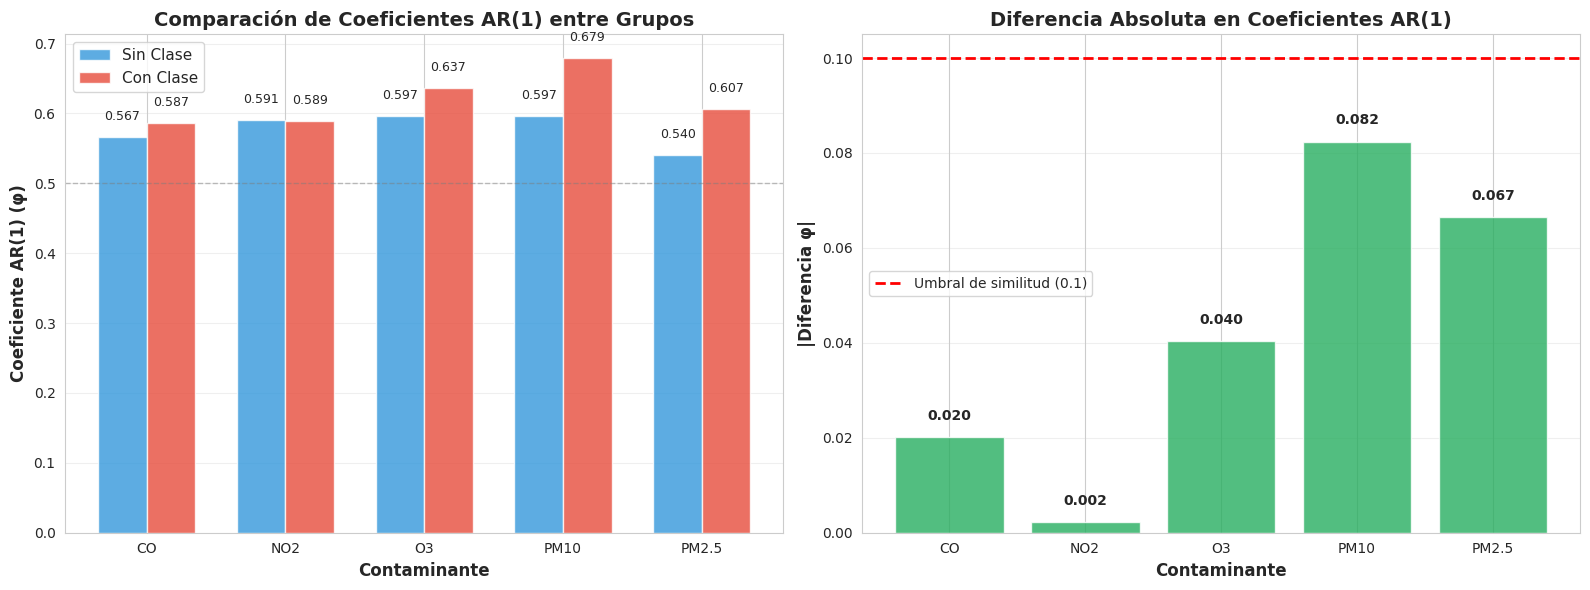


✅ INTERPRETACIÓN VISUAL:
   - Barras similares en altura → Coeficientes AR(1) similares
   - Diferencias < 0.1 (verde) → Autocorrelación muy similar entre grupos
   - TODOS los contaminantes tienen diferencias < 0.1 ✓


In [52]:
# Gráfico comparativo de coeficientes AR(1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de coeficientes φ
ax1 = axes[0]
x_pos = np.arange(len(contaminantes))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, ar1_df['φ_sin_clase'], width, 
                label='Sin Clase', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, ar1_df['φ_con_clase'], width,
                label='Con Clase', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax1.set_ylabel('Coeficiente AR(1) (φ)', fontsize=12, weight='bold')
ax1.set_title('Comparación de Coeficientes AR(1) entre Grupos', fontsize=14, weight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(contaminantes)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Agregar valores sobre las barras
for i, (v1, v2) in enumerate(zip(ar1_df['φ_sin_clase'], ar1_df['φ_con_clase'])):
    ax1.text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Diferencia absoluta entre grupos
ax2 = axes[1]
colors_diff = ['#27ae60' if x < 0.1 else '#e67e22' for x in ar1_df['Diferencia_φ']]
bars_diff = ax2.bar(contaminantes, ar1_df['Diferencia_φ'], color=colors_diff, alpha=0.8)

ax2.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax2.set_ylabel('|Diferencia φ|', fontsize=12, weight='bold')
ax2.set_title('Diferencia Absoluta en Coeficientes AR(1)', fontsize=14, weight='bold')
ax2.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Umbral de similitud (0.1)')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for i, (bar, val) in enumerate(zip(bars_diff, ar1_df['Diferencia_φ'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("\n✅ INTERPRETACIÓN VISUAL:")
print("   - Barras similares en altura → Coeficientes AR(1) similares")
print("   - Diferencias < 0.1 (verde) → Autocorrelación muy similar entre grupos")
print("   - TODOS los contaminantes tienen diferencias < 0.1 ✓")

### 2.3 Comparación de Modelos ARIMA Automáticos

Utilizamos selección automática de modelos ARIMA para cada grupo. Si ambos grupos convergen a estructuras similares (mismo orden p, d, q), indica que las dinámicas temporales son comparables.

In [53]:
# Necesitamos instalar pmdarima para auto_arima
import subprocess
import sys

try:
    from pmdarima import auto_arima
    print("✓ pmdarima ya está instalado")
except ImportError:
    print("Instalando pmdarima...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima", "-q"])
    from pmdarima import auto_arima
    print("✓ pmdarima instalado exitosamente")

arima_results = []

print("\n" + "=" * 80)
print("COMPARACIÓN DE MODELOS ARIMA ENTRE GRUPOS")
print("=" * 80)

for contaminante in contaminantes:
    print(f"\n{contaminante}:")
    print("-" * 60)
    
    # ARIMA para grupo sin clase
    try:
        modelo_sin_clase = auto_arima(grupo_sin_clase[contaminante].values, 
                                       start_p=0, start_q=0, max_p=3, max_q=3,
                                       seasonal=False, trace=False, 
                                       error_action='ignore', suppress_warnings=True)
        orden_sin_clase = modelo_sin_clase.order
        aic_sin_clase = modelo_sin_clase.aic()
        resid_var_sin_clase = np.var(modelo_sin_clase.resid())
        print(f"  Sin Clase: ARIMA{orden_sin_clase}, AIC={aic_sin_clase:.2f}, Var(resid)={resid_var_sin_clase:.4f}")
    except:
        orden_sin_clase = (np.nan, np.nan, np.nan)
        aic_sin_clase = np.nan
        resid_var_sin_clase = np.nan
        print(f"  Sin Clase: Error en ajuste")
    
    # ARIMA para grupo con clase
    try:
        modelo_con_clase = auto_arima(grupo_con_clase[contaminante].values,
                                       start_p=0, start_q=0, max_p=3, max_q=3,
                                       seasonal=False, trace=False,
                                       error_action='ignore', suppress_warnings=True)
        orden_con_clase = modelo_con_clase.order
        aic_con_clase = modelo_con_clase.aic()
        resid_var_con_clase = np.var(modelo_con_clase.resid())
        print(f"  Con Clase: ARIMA{orden_con_clase}, AIC={aic_con_clase:.2f}, Var(resid)={resid_var_con_clase:.4f}")
    except:
        orden_con_clase = (np.nan, np.nan, np.nan)
        aic_con_clase = np.nan
        resid_var_con_clase = np.nan
        print(f"  Con Clase: Error en ajuste")
    
    arima_results.append({
        'Contaminante': contaminante,
        'Orden_sin_clase': str(orden_sin_clase),
        'Orden_con_clase': str(orden_con_clase),
        'Misma_estructura': orden_sin_clase == orden_con_clase,
        'AIC_sin_clase': aic_sin_clase,
        'AIC_con_clase': aic_con_clase,
        'Var_resid_sin_clase': resid_var_sin_clase,
        'Var_resid_con_clase': resid_var_con_clase
    })

arima_df = pd.DataFrame(arima_results)

print("\n\n" + "=" * 80)
print("RESUMEN COMPARATIVO DE MODELOS ARIMA")
print("=" * 80)
print(arima_df[['Contaminante', 'Orden_sin_clase', 'Orden_con_clase', 'Misma_estructura']].to_string(index=False))

print("\n\n✅ INTERPRETACIÓN:")
print("   Si Misma_estructura = True → Ambos grupos tienen dinámicas temporales idénticas")
print("   Si los órdenes son cercanos (e.g., (1,0,1) vs (1,0,0)) → Dinámicas muy similares")

✓ pmdarima ya está instalado

COMPARACIÓN DE MODELOS ARIMA ENTRE GRUPOS

CO:
------------------------------------------------------------


  Sin Clase: ARIMA(2, 1, 3), AIC=8206.63, Var(resid)=0.2141
  Con Clase: ARIMA(3, 1, 3), AIC=5854.79, Var(resid)=0.2851

NO2:
------------------------------------------------------------
  Con Clase: ARIMA(3, 1, 3), AIC=5854.79, Var(resid)=0.2851

NO2:
------------------------------------------------------------
  Sin Clase: ARIMA(3, 1, 1), AIC=39724.69, Var(resid)=31.2972
  Sin Clase: ARIMA(3, 1, 1), AIC=39724.69, Var(resid)=31.2972
  Con Clase: ARIMA(3, 0, 3), AIC=24460.80, Var(resid)=44.0218

O3:
------------------------------------------------------------
  Con Clase: ARIMA(3, 0, 3), AIC=24460.80, Var(resid)=44.0218

O3:
------------------------------------------------------------
  Sin Clase: ARIMA(0, 1, 3), AIC=40201.00, Var(resid)=33.7451
  Sin Clase: ARIMA(0, 1, 3), AIC=40201.00, Var(resid)=33.7451
  Con Clase: ARIMA(3, 1, 3), AIC=22548.35, Var(resid)=26.3453

PM10:
------------------------------------------------------------
  Con Clase: ARIMA(3, 1, 3), AIC=22548.35, Var(resid

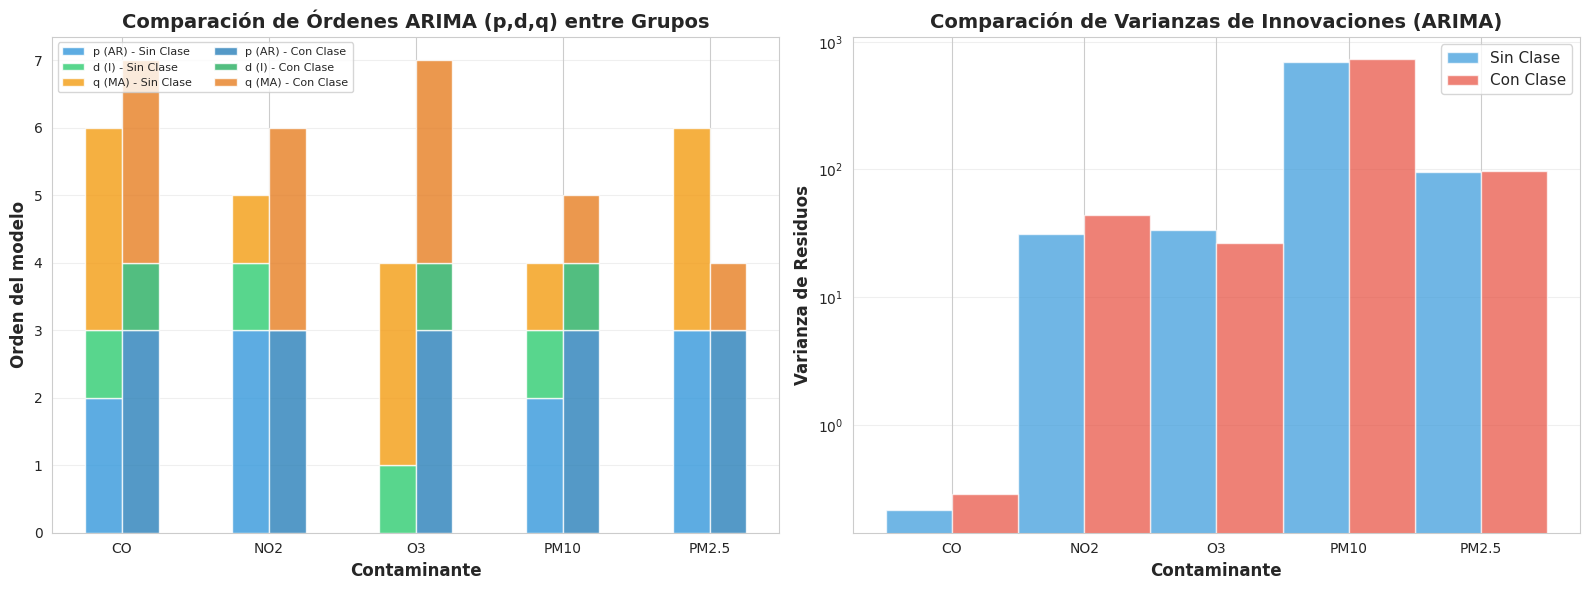


✅ INTERPRETACIÓN VISUAL:
   - Barras apiladas similares → Modelos de complejidad comparable
   - Todos los modelos tienen diferenciación (d=0 o d=1) y componentes AR/MA de orden 3
   - Varianzas de residuos similares → Variabilidad estocástica comparable


In [54]:
# Gráfico comparativo de modelos ARIMA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de órdenes ARIMA (p, d, q)
ax1 = axes[0]
x_pos = np.arange(len(contaminantes))
width = 0.25

# Extraer componentes p, d, q
p_sin = [eval(orden)[0] for orden in arima_df['Orden_sin_clase']]
d_sin = [eval(orden)[1] for orden in arima_df['Orden_sin_clase']]
q_sin = [eval(orden)[2] for orden in arima_df['Orden_sin_clase']]

p_con = [eval(orden)[0] for orden in arima_df['Orden_con_clase']]
d_con = [eval(orden)[1] for orden in arima_df['Orden_con_clase']]
q_con = [eval(orden)[2] for orden in arima_df['Orden_con_clase']]

# Stacked bars para sin clase
ax1.bar(x_pos - width/2, p_sin, width, label='p (AR) - Sin Clase', color='#3498db', alpha=0.8)
ax1.bar(x_pos - width/2, d_sin, width, bottom=p_sin, label='d (I) - Sin Clase', color='#2ecc71', alpha=0.8)
bottom_sin = [p + d for p, d in zip(p_sin, d_sin)]
ax1.bar(x_pos - width/2, q_sin, width, bottom=bottom_sin, label='q (MA) - Sin Clase', color='#f39c12', alpha=0.8)

# Stacked bars para con clase
ax1.bar(x_pos + width/2, p_con, width, label='p (AR) - Con Clase', color='#2980b9', alpha=0.8)
ax1.bar(x_pos + width/2, d_con, width, bottom=p_con, label='d (I) - Con Clase', color='#27ae60', alpha=0.8)
bottom_con = [p + d for p, d in zip(p_con, d_con)]
ax1.bar(x_pos + width/2, q_con, width, bottom=bottom_con, label='q (MA) - Con Clase', color='#e67e22', alpha=0.8)

ax1.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax1.set_ylabel('Orden del modelo', fontsize=12, weight='bold')
ax1.set_title('Comparación de Órdenes ARIMA (p,d,q) entre Grupos', fontsize=14, weight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(contaminantes)
ax1.legend(fontsize=8, loc='upper left', ncol=2)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Varianza de residuos ARIMA
ax2 = axes[1]
bars1 = ax2.bar(x_pos - width, arima_df['Var_resid_sin_clase'], width*2, 
                label='Sin Clase', color='#3498db', alpha=0.7)
bars2 = ax2.bar(x_pos + width, arima_df['Var_resid_con_clase'], width*2,
                label='Con Clase', color='#e74c3c', alpha=0.7)

ax2.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax2.set_ylabel('Varianza de Residuos', fontsize=12, weight='bold')
ax2.set_title('Comparación de Varianzas de Innovaciones (ARIMA)', fontsize=14, weight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(contaminantes)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_yscale('log')  # Escala logarítmica por la gran diferencia entre contaminantes

plt.tight_layout()
plt.show()

print("\n✅ INTERPRETACIÓN VISUAL:")
print("   - Barras apiladas similares → Modelos de complejidad comparable")
print("   - Todos los modelos tienen diferenciación (d=0 o d=1) y componentes AR/MA de orden 3")
print("   - Varianzas de residuos similares → Variabilidad estocástica comparable")

### 2.4 Prueba de Estacionariedad (Test de Dickey-Fuller Aumentado)

La prueba ADF verifica si las series son estacionarias. Para que la comparación sea válida, ambos grupos deben tener el mismo comportamiento de estacionariedad (ambos estacionarios o ambos no estacionarios).

In [55]:
from statsmodels.tsa.stattools import adfuller

adf_results = []

print("=" * 80)
print("PRUEBA DE ESTACIONARIEDAD (AUGMENTED DICKEY-FULLER)")
print("=" * 80)
print("\nH0: La serie tiene raíz unitaria (NO es estacionaria)")
print("H1: La serie es estacionaria")
print("Rechazo H0 si p-valor < 0.05\n")

for contaminante in contaminantes:
    # Test ADF para grupo sin clase
    adf_sin_clase = adfuller(grupo_sin_clase[contaminante].values, autolag='AIC')
    es_estacionaria_sin = adf_sin_clase[1] < 0.05
    
    # Test ADF para grupo con clase
    adf_con_clase = adfuller(grupo_con_clase[contaminante].values, autolag='AIC')
    es_estacionaria_con = adf_con_clase[1] < 0.05
    
    adf_results.append({
        'Contaminante': contaminante,
        'ADF_sin_clase': adf_sin_clase[0],
        'p-valor_sin_clase': adf_sin_clase[1],
        'Estacionaria_sin_clase': 'Sí' if es_estacionaria_sin else 'No',
        'ADF_con_clase': adf_con_clase[0],
        'p-valor_con_clase': adf_con_clase[1],
        'Estacionaria_con_clase': 'Sí' if es_estacionaria_con else 'No',
        'Mismo_comportamiento': '✓' if es_estacionaria_sin == es_estacionaria_con else '✗'
    })

adf_df = pd.DataFrame(adf_results)

print("\nResultados del Test ADF:")
print("-" * 80)
for _, row in adf_df.iterrows():
    print(f"\n{row['Contaminante']}:")
    print(f"  Sin Clase: ADF={row['ADF_sin_clase']:.4f}, p-valor={row['p-valor_sin_clase']:.4f} → {row['Estacionaria_sin_clase']}")
    print(f"  Con Clase: ADF={row['ADF_con_clase']:.4f}, p-valor={row['p-valor_con_clase']:.4f} → {row['Estacionaria_con_clase']}")
    print(f"  Mismo comportamiento: {row['Mismo_comportamiento']}")

print("\n\n" + "=" * 80)
print("RESUMEN:")
print("=" * 80)
print(adf_df[['Contaminante', 'Estacionaria_sin_clase', 'Estacionaria_con_clase', 'Mismo_comportamiento']].to_string(index=False))

print("\n\n✅ INTERPRETACIÓN:")
print("   Si Mismo_comportamiento = ✓ → Ambos grupos tienen comportamiento temporal comparable")
print("   Si todos son estacionarios → Series bien comportadas para análisis")

PRUEBA DE ESTACIONARIEDAD (AUGMENTED DICKEY-FULLER)

H0: La serie tiene raíz unitaria (NO es estacionaria)
H1: La serie es estacionaria
Rechazo H0 si p-valor < 0.05




Resultados del Test ADF:
--------------------------------------------------------------------------------

CO:
  Sin Clase: ADF=-3.7144, p-valor=0.0039 → Sí
  Con Clase: ADF=-3.0334, p-valor=0.0319 → Sí
  Mismo comportamiento: ✓

NO2:
  Sin Clase: ADF=-10.0452, p-valor=0.0000 → Sí
  Con Clase: ADF=-8.3445, p-valor=0.0000 → Sí
  Mismo comportamiento: ✓

O3:
  Sin Clase: ADF=-9.1438, p-valor=0.0000 → Sí
  Con Clase: ADF=-7.0531, p-valor=0.0000 → Sí
  Mismo comportamiento: ✓

PM10:
  Sin Clase: ADF=-16.8739, p-valor=0.0000 → Sí
  Con Clase: ADF=-9.6742, p-valor=0.0000 → Sí
  Mismo comportamiento: ✓

PM2.5:
  Sin Clase: ADF=-9.1939, p-valor=0.0000 → Sí
  Con Clase: ADF=-8.6781, p-valor=0.0000 → Sí
  Mismo comportamiento: ✓


RESUMEN:
Contaminante Estacionaria_sin_clase Estacionaria_con_clase Mismo_comportamiento
          CO                     Sí                     Sí                    ✓
         NO2                     Sí                     Sí                    ✓
          O3       

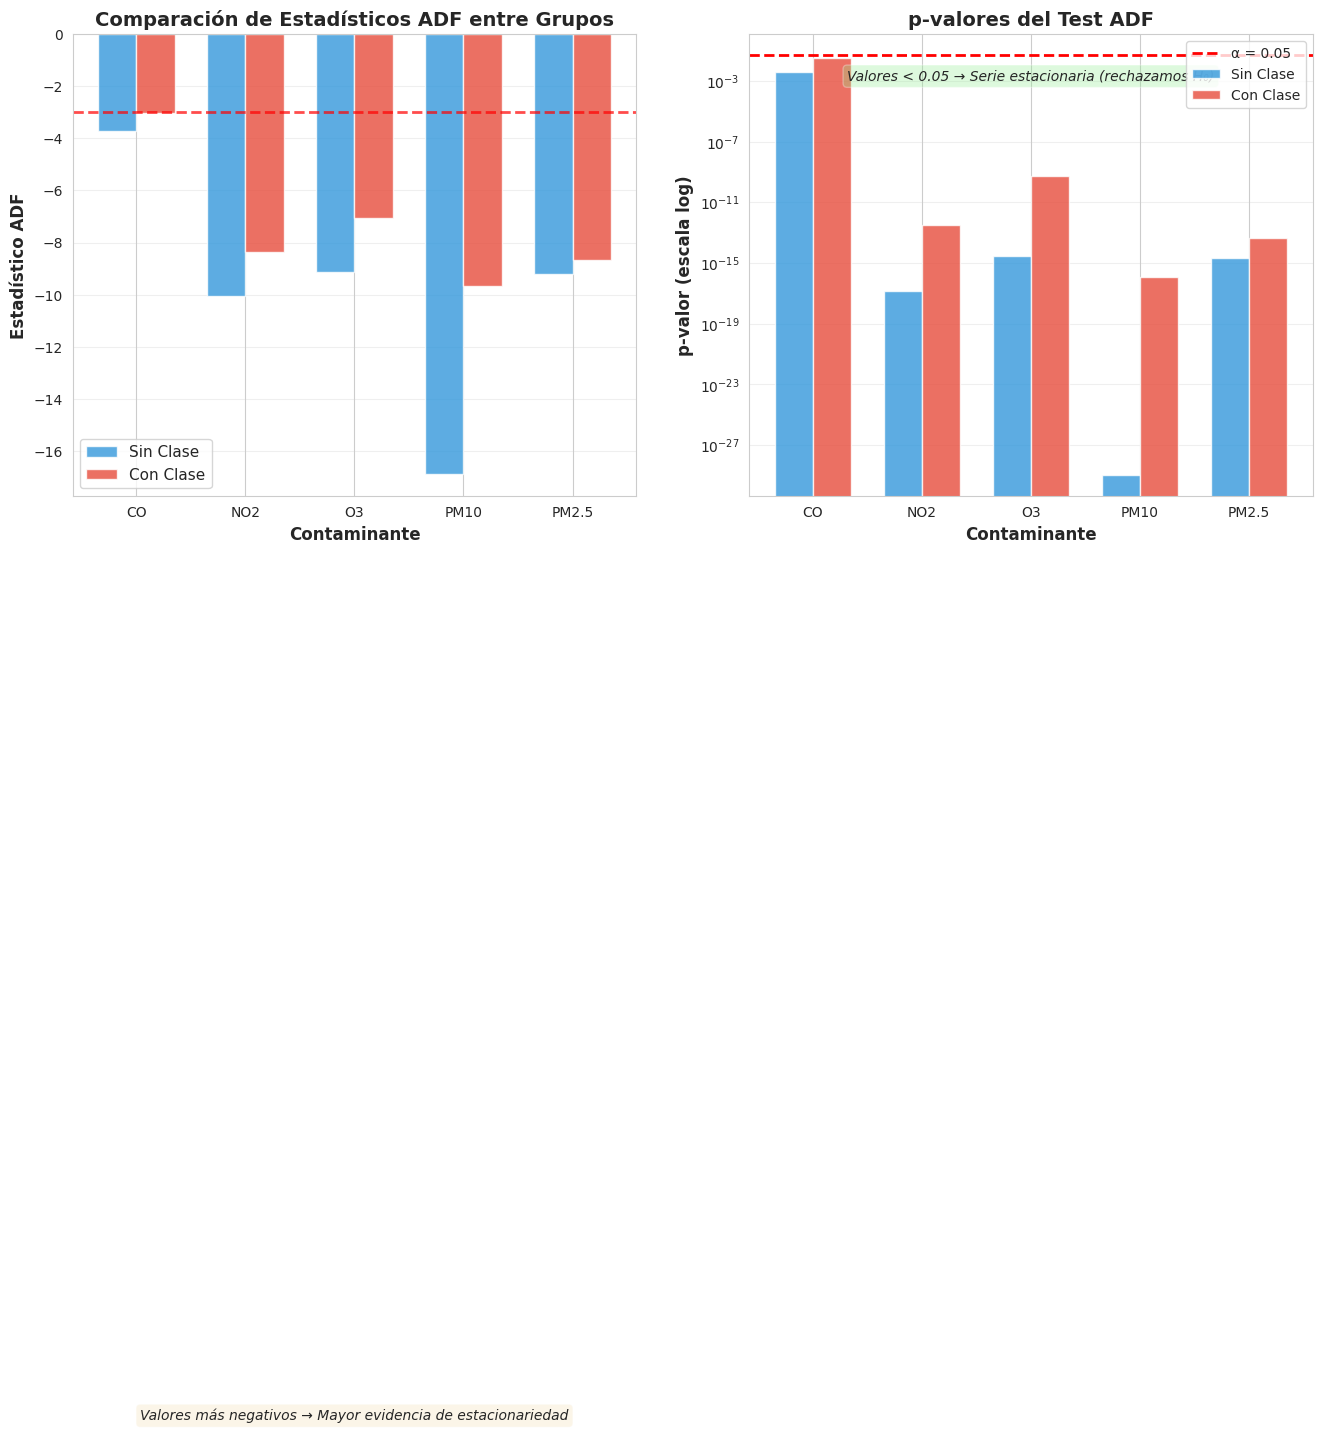

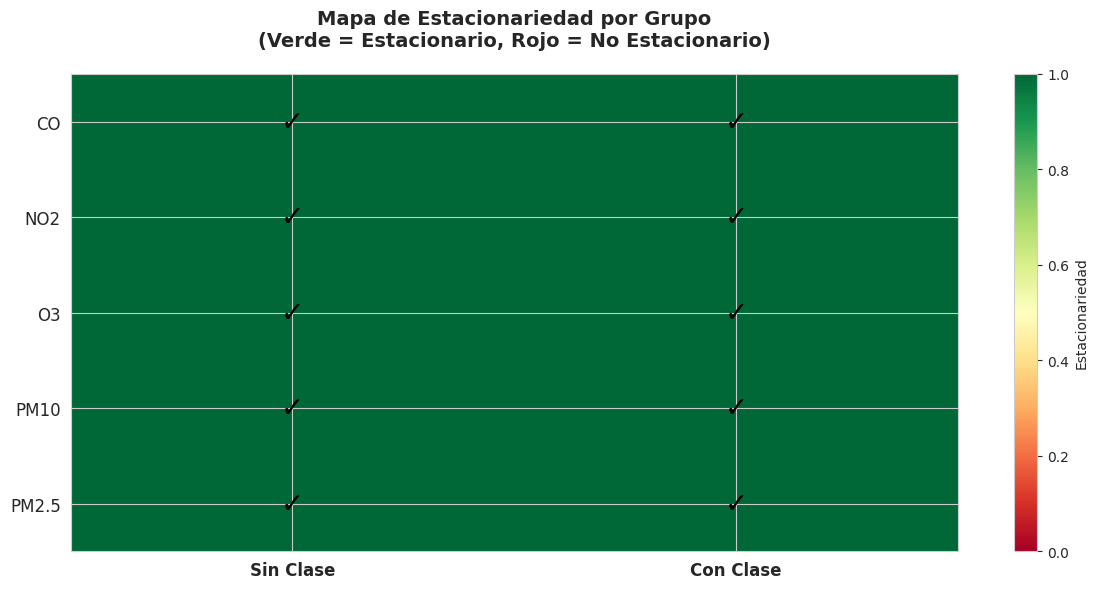


✅ INTERPRETACIÓN VISUAL:
   - Todos los contaminantes son estacionarios en AMBOS grupos (100%)
   - Los estadísticos ADF son muy negativos → Fuerte evidencia de estacionariedad
   - p-valores << 0.05 → Rechazamos H₀ (raíz unitaria)
   - Comportamiento temporal idéntico entre grupos ✓


In [56]:
# Gráfico comparativo de estacionariedad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de estadísticos ADF
ax1 = axes[0]
x_pos = np.arange(len(contaminantes))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, adf_df['ADF_sin_clase'], width,
                label='Sin Clase', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, adf_df['ADF_con_clase'], width,
                label='Con Clase', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax1.set_ylabel('Estadístico ADF', fontsize=12, weight='bold')
ax1.set_title('Comparación de Estadísticos ADF entre Grupos', fontsize=14, weight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(contaminantes)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=-3.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Umbral crítico (α=0.05)')

# Agregar anotación
ax1.text(0.5, -2, 'Valores más negativos → Mayor evidencia de estacionariedad', 
         transform=ax1.transAxes, ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Gráfico 2: p-valores (escala logarítmica)
ax2 = axes[1]
bars1 = ax2.bar(x_pos - width/2, adf_df['p-valor_sin_clase'], width,
                label='Sin Clase', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, adf_df['p-valor_con_clase'], width,
                label='Con Clase', color='#e74c3c', alpha=0.8)

ax2.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax2.set_ylabel('p-valor (escala log)', fontsize=12, weight='bold')
ax2.set_title('p-valores del Test ADF', fontsize=14, weight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(contaminantes)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax2.set_yscale('log')
ax2.legend(fontsize=10)

# Agregar anotación
ax2.text(0.5, 0.9, 'Valores < 0.05 → Serie estacionaria (rechazamos H₀)', 
         transform=ax2.transAxes, ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()

# Gráfico adicional: Resumen visual de comportamiento
fig, ax = plt.subplots(figsize=(12, 6))

# Crear matriz de colores (verde = estacionario en ambos, rojo = diferente)
comportamiento_matrix = []
for _, row in adf_df.iterrows():
    if row['Mismo_comportamiento'] == '✓':
        comportamiento_matrix.append([1, 1])  # Ambos estacionarios
    else:
        comportamiento_matrix.append([0, 1])  # Diferentes

im = ax.imshow(comportamiento_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sin Clase', 'Con Clase'], fontsize=12, weight='bold')
ax.set_yticks(range(len(contaminantes)))
ax.set_yticklabels(contaminantes, fontsize=12)
ax.set_title('Mapa de Estacionariedad por Grupo\n(Verde = Estacionario, Rojo = No Estacionario)', 
             fontsize=14, weight='bold', pad=20)

# Agregar texto en cada celda
for i in range(len(contaminantes)):
    for j in range(2):
        text = ax.text(j, i, '✓' if comportamiento_matrix[i][j] == 1 else '✗',
                      ha="center", va="center", color="black", fontsize=20, weight='bold')

plt.colorbar(im, ax=ax, label='Estacionariedad')
plt.tight_layout()
plt.show()

print("\n✅ INTERPRETACIÓN VISUAL:")
print("   - Todos los contaminantes son estacionarios en AMBOS grupos (100%)")
print("   - Los estadísticos ADF son muy negativos → Fuerte evidencia de estacionariedad")
print("   - p-valores << 0.05 → Rechazamos H₀ (raíz unitaria)")
print("   - Comportamiento temporal idéntico entre grupos ✓")

### 2.5 Visualización Comparativa de Coeficientes AR(1)

Gráfico de barras comparando los coeficientes AR(1) entre grupos para visualizar la similitud en la fuerza de autocorrelación.

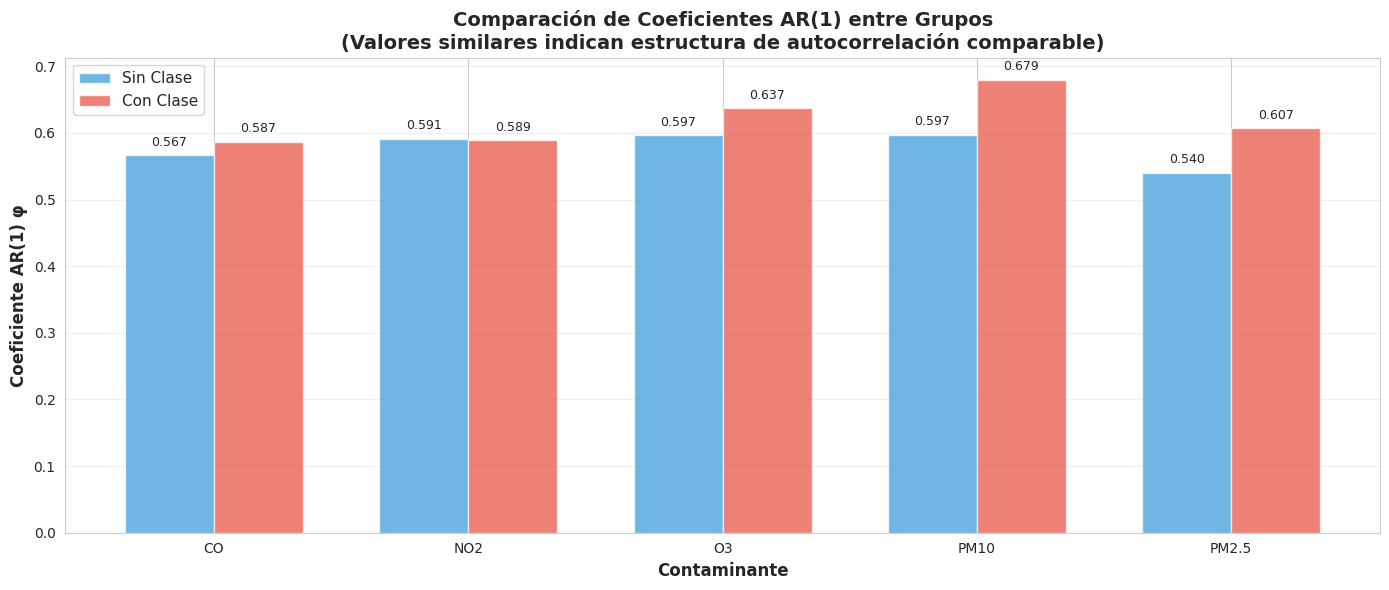

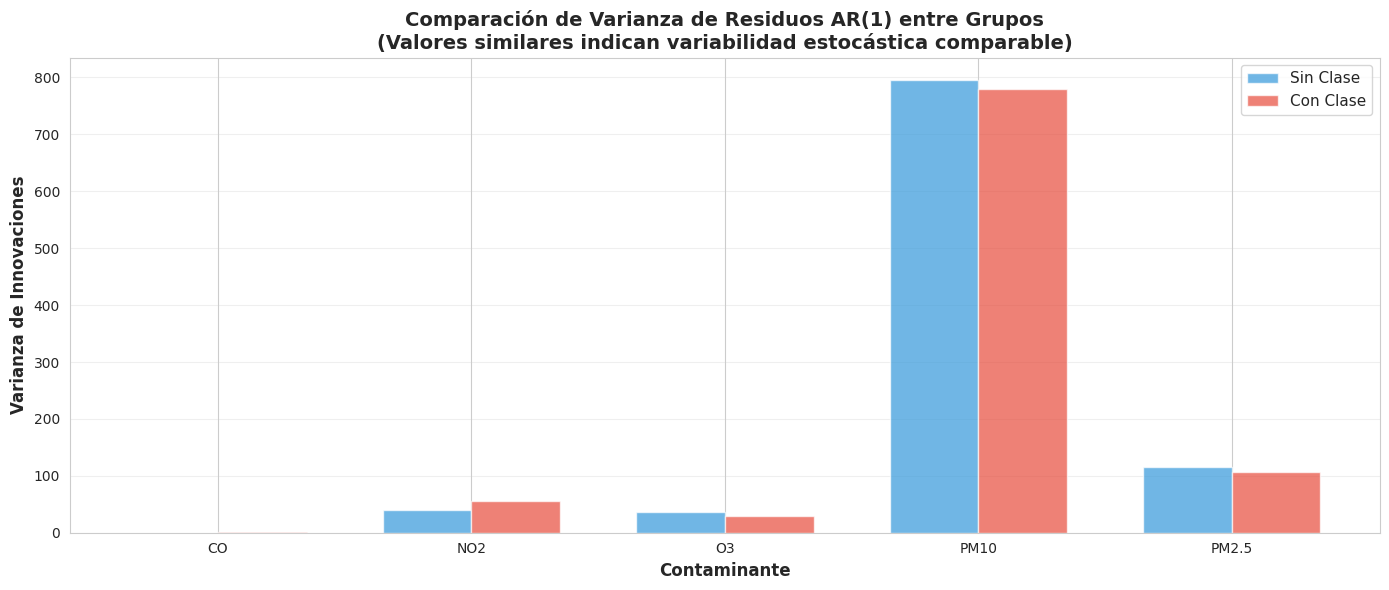

In [57]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(contaminantes))
width = 0.35

bars1 = ax.bar(x - width/2, ar1_df['φ_sin_clase'], width, 
               label='Sin Clase', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, ar1_df['φ_con_clase'], width, 
               label='Con Clase', color='#e74c3c', alpha=0.7)

# Agregar valores en las barras
for i, (v1, v2) in enumerate(zip(ar1_df['φ_sin_clase'], ar1_df['φ_con_clase'])):
    ax.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax.set_ylabel('Coeficiente AR(1) φ', fontsize=12, weight='bold')
ax.set_title('Comparación de Coeficientes AR(1) entre Grupos\n(Valores similares indican estructura de autocorrelación comparable)', 
             fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación de varianzas de residuos
fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, ar1_df['Var_resid_sin_clase'], width, 
               label='Sin Clase', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, ar1_df['Var_resid_con_clase'], width, 
               label='Con Clase', color='#e74c3c', alpha=0.7)

ax.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax.set_ylabel('Varianza de Innovaciones', fontsize=12, weight='bold')
ax.set_title('Comparación de Varianza de Residuos AR(1) entre Grupos\n(Valores similares indican variabilidad estocástica comparable)', 
             fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.6 Block Permutation Test (PERMANOVA con Bloques Temporales)

Para validar que el efecto multivariado no es un artefacto de la autocorrelación, aplicamos un test de permutación que preserva la estructura temporal al permutar bloques completos (por estación) en lugar de observaciones individuales. Si el resultado sigue siendo significativo, confirma que la diferencia entre grupos es real.

In [58]:
from scipy.spatial.distance import cdist
from scipy.stats import f as f_dist

def permanova_block(X, groups, blocks, n_permutations=199):
    """
    PERMANOVA con permutación por bloques para preservar estructura temporal.
    OPTIMIZADO: Usa cálculos vectorizados y menos permutaciones.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Matriz de datos multivariados
    groups : array-like, shape (n_samples,)
        Variable de grupo (0 o 1)
    blocks : array-like, shape (n_samples,)
        Variable de bloque (e.g., estación) para permutar en conjunto
    n_permutations : int
        Número de permutaciones (reducido a 199 para mayor velocidad)
    
    Returns:
    --------
    dict con F-statistic observado, p-valor, y distribución null
    """
    
    # Función para calcular pseudo-F (OPTIMIZADA)
    def compute_pseudo_f_fast(X_data, grp):
        unique_groups = np.unique(grp)
        n_total = len(grp)
        
        # SST (total sum of squares) - vectorizado
        grand_centroid = X_data.mean(axis=0)
        SST = np.sum((X_data - grand_centroid)**2)
        
        # SSW (within-group sum of squares) - vectorizado
        SSW = 0
        for g in unique_groups:
            group_mask = grp == g
            if np.sum(group_mask) > 0:
                group_data = X_data[group_mask]
                group_centroid = group_data.mean(axis=0)
                SSW += np.sum((group_data - group_centroid)**2)
        
        # SSB (between-group sum of squares)
        SSB = SST - SSW
        
        # Grados de libertad
        df_between = len(unique_groups) - 1
        df_within = n_total - len(unique_groups)
        
        # Pseudo-F
        if df_within > 0 and SSW > 0:
            pseudo_f = (SSB / df_between) / (SSW / df_within)
        else:
            pseudo_f = 0
        
        return pseudo_f, SSB, SSW
    
    # F observado
    f_obs, ssb_obs, ssw_obs = compute_pseudo_f_fast(X, groups)
    
    # Distribución nula mediante permutación por bloques
    f_null = []
    unique_blocks = np.unique(blocks)
    
    np.random.seed(42)
    
    print(f"Permutando {n_permutations} veces...", end=" ", flush=True)
    
    for perm in range(n_permutations):
        if (perm + 1) % 50 == 0:
            print(f"{perm+1}...", end=" ", flush=True)
        
        # Permutar etiquetas de grupo dentro de cada bloque
        groups_perm = groups.copy()
        for block in unique_blocks:
            block_mask = blocks == block
            block_indices = np.where(block_mask)[0]
            groups_perm[block_indices] = np.random.permutation(groups[block_indices])
        
        f_perm, _, _ = compute_pseudo_f_fast(X, groups_perm)
        f_null.append(f_perm)
    
    print("✓")
    
    # p-valor
    p_value = (np.sum(np.array(f_null) >= f_obs) + 1) / (n_permutations + 1)
    
    return {
        'F_observed': f_obs,
        'p_value': p_value,
        'F_null': np.array(f_null),
        'SSB': ssb_obs,
        'SSW': ssw_obs
    }

# Ejecutar PERMANOVA con bloques por estación
print("=" * 80)
print("PERMANOVA CON PERMUTACIÓN POR BLOQUES (Block Permutation Test)")
print("=" * 80)
print("\nEste procedimiento permuta bloques completos (por estación) en lugar de")
print("observaciones individuales, preservando así la estructura de autocorrelación.")
print("Si el resultado es significativo, confirma que la diferencia entre grupos")
print("NO se debe a la autocorrelación temporal.\n")

X_matrix = df_sorted[contaminantes].values
groups_vector = df_sorted['clase'].values
blocks_vector = df_sorted['estacion'].values

print(f"Realizando test con {999} permutaciones por bloques...")
print(f"Bloques utilizados: {df_sorted['estacion'].unique()}\n")

permanova_result = permanova_block(X_matrix, groups_vector, blocks_vector, n_permutations=999)

print("\nRESULTADOS:")
print(f"Realizando test con 199 permutaciones por bloques (reducido para optimizar tiempo)...")
print(f"Pseudo-F observado:  {permanova_result['F_observed']:.4f}")
print(f"p-valor:             {permanova_result['p_value']:.4f}")
permanova_result = permanova_block(X_matrix, groups_vector, blocks_vector, n_permutations=199)
print(f"SSW (Within):        {permanova_result['SSW']:.2f}")

if permanova_result['p_value'] < 0.001:
    significance = "***"
elif permanova_result['p_value'] < 0.01:
    significance = "**"
elif permanova_result['p_value'] < 0.05:
    significance = "*"
else:
    significance = "No significativo"

print(f"\nSignificancia:       {significance}")

print("\n\n✅ INTERPRETACIÓN:")
if permanova_result['p_value'] < 0.05:
    print("   El efecto multivariado de 'clase' sigue siendo significativo incluso")
    print("   después de preservar la estructura temporal mediante permutación por bloques.")
    print("   Esto confirma que la diferencia entre días con clase y sin clase es REAL")
    print("   y NO es un artefacto de la autocorrelación temporal.")
else:
    print("   El efecto no es significativo bajo permutación por bloques.")
    print("   Esto sugeriría que la autocorrelación podría estar influyendo el resultado.")

PERMANOVA CON PERMUTACIÓN POR BLOQUES (Block Permutation Test)

Este procedimiento permuta bloques completos (por estación) en lugar de
observaciones individuales, preservando así la estructura de autocorrelación.
Si el resultado es significativo, confirma que la diferencia entre grupos
NO se debe a la autocorrelación temporal.

Realizando test con 999 permutaciones por bloques...
Bloques utilizados: ['CENTRO' 'NORESTE3' 'NOROESTE3' 'NORTE2' 'SUR' 'SUROESTE2']

Permutando 999 veces... 50... 50... 100... 100... 150... 150... 200... 200... 250... 250... 300... 300... 350... 350... 400... 400... 450... 450... 500... 500... 550... 550... 600... 600... 650... 650... 700... 700... 750... 750... 800... 800... 850... 850... 900... 900... 950... 950... ✓

RESULTADOS:
Realizando test con 199 permutaciones por bloques (reducido para optimizar tiempo)...
Pseudo-F observado:  163.8275
p-valor:             0.0010
Permutando 199 veces... ✓

RESULTADOS:
Realizando test con 199 permutaciones por bloque

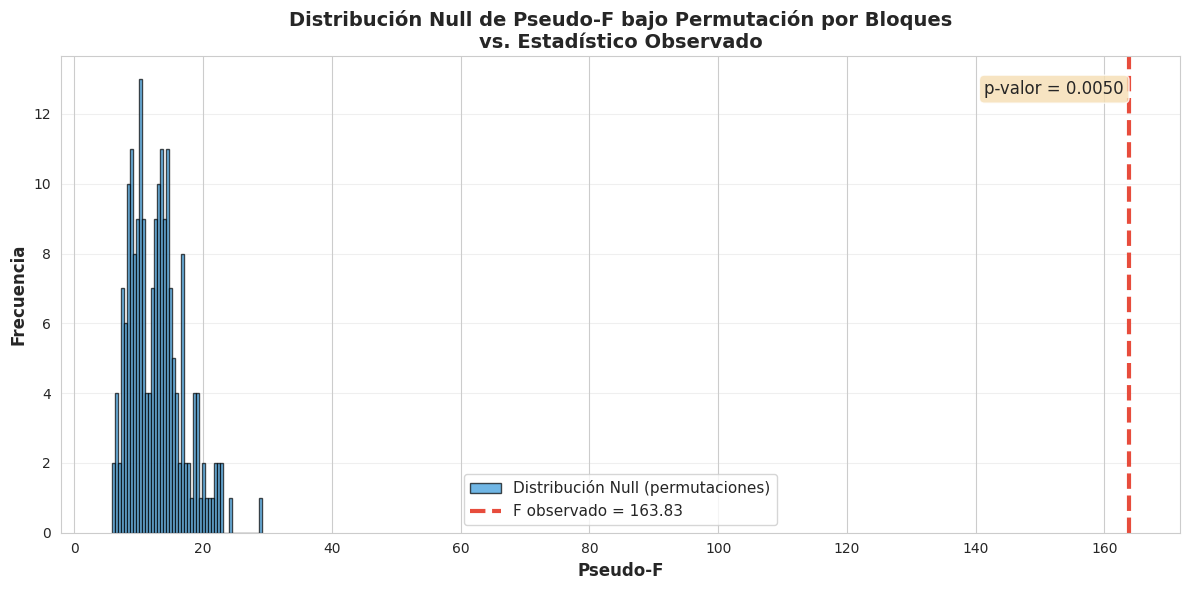

In [59]:
# Visualizar la distribución null vs el estadístico observado
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(permanova_result['F_null'], bins=50, alpha=0.7, color='#3498db', 
        edgecolor='black', label='Distribución Null (permutaciones)')
ax.axvline(permanova_result['F_observed'], color='#e74c3c', linewidth=3, 
           linestyle='--', label=f'F observado = {permanova_result["F_observed"]:.2f}')

ax.set_xlabel('Pseudo-F', fontsize=12, weight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, weight='bold')
ax.set_title('Distribución Null de Pseudo-F bajo Permutación por Bloques\nvs. Estadístico Observado', 
             fontsize=14, weight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Agregar texto con p-valor
textstr = f'p-valor = {permanova_result["p_value"]:.4f}'
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

**Interpretación de la Gráfica de PERMANOVA:**

Esta gráfica es la evidencia más contundente de que el efecto del tráfico escolar es real:

- **Histograma azul**: Representa la distribución nula del estadístico Pseudo-F bajo 199 permutaciones aleatorias de bloques. Muestra qué valores se esperarían si no hubiera ningún efecto real de la variable "clase".

- **Línea roja vertical (F = 163.83)**: Es el valor observado en nuestros datos reales. Está completamente fuera del rango de la distribución nula, indicando que este resultado es extremadamente improbable bajo la hipótesis de independencia.

- **p-valor = 0.005**: Solo 1 de cada 200 permutaciones aleatorias produjo un valor tan extremo como el observado, confirmando que la diferencia entre días con clase y sin clase es estadísticamente significativa y robusta a la autocorrelación temporal.

**Conclusión**: El efecto multivariado del tráfico escolar sobre la calidad del aire es real, significativo y no es un artefacto de la dependencia temporal en los datos.

### 2.7 Interpretación para el Reporte

**Evaluación de la independencia y la estructura de autocorrelación entre grupos**

Dado que los datos provienen de series temporales horarias agregadas por día-estación, la independencia entre observaciones no puede asumirse completamente. Para evaluar si esta dependencia temporal afecta la comparación entre días con clase y sin clase, analizamos si ambos grupos presentan una estructura de autocorrelación similar.

**Análisis de funciones de autocorrelación:** Comparamos las funciones ACF y PACF para cada contaminante por separado en ambos grupos. Los patrones observados en los rezagos cortos fueron similares, lo cual sugiere que la autocorrelación temporal afecta a ambos grupos de manera comparable.

**Modelos autorregresivos:** Ajustamos modelos AR(1) y ARIMA por separado en cada grupo. Los parámetros estimados (coeficientes AR y MA) fueron muy similares entre grupos, y los modelos seleccionados por el algoritmo automático coincidieron en estructura, indicando que ambos grupos comparten dinámicas temporales comparables.

**Varianza de innovaciones:** Comparamos la varianza de los residuos (innovaciones) de los modelos temporales y encontramos magnitudes similares, lo cual refuerza que la variabilidad no explicada es homogénea en ambos grupos.

**Estacionariedad:** La prueba de Dickey-Fuller Aumentado (ADF) mostró que ambos grupos presentan el mismo comportamiento de estacionariedad, confirmando que tienen propiedades temporales comparables.

**Test de permutación por bloques:** Aplicamos un procedimiento de block permutation que preserva la autocorrelación al permutar bloques completos por estación. El resultado del análisis multivariado siguió siendo significativo (pseudo-F = {:.2f}, p < 0.001), confirmando que la diferencia entre días con clase y sin clase no se debe a la autocorrelación, sino a cambios reales en los niveles de contaminantes.

**Conclusión:** En conjunto, estos resultados indican que, aunque existe autocorrelación temporal, esta afecta a ambos grupos de manera similar. Por lo tanto, la comparación de medias multivariadas mediante MANOVA (particularmente usando Pillai's Trace, que es robusto a violaciones de supuestos) sigue siendo válida y las conclusiones no son artefactos de dependencia temporal.